# 006. 小型 GPT の事前学習(Pretraining a Small GPT)

## 1. 概要 / Overview

001〜005 で個別に検証してきた部品(多頭注意機構、Transformer Block、RoPE、RMSNorm、SwiGLU、トークナイザ)を統合し、**decoder-only な自己回帰言語モデル(Autoregressive Language Model)を実際に事前学習(pretraining)させる** 初めてのトピックである。あわせて、005 で比較したトークナイザ(方式・語彙サイズ)を下流の言語モデリング性能(bits-per-byte)で選定する。日本語版・英語版 Wikipedia のコーパスを用い、トークナイザ条件間・語彙サイズ間の比較を、測定ノイズ床(noise floor)を基準にした判定基準のもとで行う。

## 2. 参考論文 / References

| # | 著者 / Authors | タイトル / Title | 会議・媒体 / Venue | URL |
|---|---|---|---|---|
| [1] | Radford, A., Narasimhan, K., Salimans, T., Sutskever, I. | Improving Language Understanding by Generative Pre-Training | OpenAI, 2018 | https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf |
| [2] | Radford, A., Wu, J., Child, R., Luan, D., Amodei, D., Sutskever, I. | Language Models are Unsupervised Multitask Learners | OpenAI, 2019 | https://d4mucfpksyws.cloudfront.net/better-language-models/language-models.pdf |
| [3] | Brown, T. B., et al. | Language Models are Few-Shot Learners | NeurIPS 2020 | https://arxiv.org/abs/2005.14165 |
| [4] | Press, O., Wolf, L. | Using the Output Embedding to Improve Language Models | EACL 2017 | https://arxiv.org/abs/1608.05859 |
| [5] | Inan, H., Khosravi, K., Socher, R. | Tying Word Vectors and Word Classifiers: A Loss Framework for Language Modeling | ICLR 2017 | https://arxiv.org/abs/1611.01462 |
| [6] | Kaplan, J., et al. | Scaling Laws for Neural Language Models | 2020 | https://arxiv.org/abs/2001.08361 |
| [7] | Touvron, H., et al. | LLaMA: Open and Efficient Foundation Language Models | 2023 | https://arxiv.org/abs/2302.13971 |

本文中で各理論に言及する際は、対応する番号(例:「decoder-only 構成 [1, 2]」)を付す。

## 3. 理論 / Theory

### 3.1 自己回帰言語モデリング(Autoregressive Language Modeling)

**記号 / Notation**:

- $x = (x_1, \dots, x_n)$: トークン ID の系列(系列長 $n$)
- $V$: 語彙サイズ(vocabulary size)
- $\theta$: モデルのパラメータ
- $p_\theta(x_t \mid x_{<t})$: パラメータ $\theta$ のもとで、位置 $t$ より前のトークン $x_{<t} = (x_1, \dots, x_{t-1})$ を条件とした位置 $t$ のトークンの予測分布

系列全体の同時分布 $p_\theta(x)$ は、確率の連鎖律(chain rule)によって、各位置の条件付き分布の積に分解できる。

$$
p_\theta(x) = \prod_{t=1}^{n} p_\theta(x_t \mid x_{<t})
$$

**自己回帰言語モデル(Autoregressive Language Model)** は、この各項 $p_\theta(x_t \mid x_{<t})$ をニューラルネットワークで直接モデル化する [1, 2]。学習は、この同時分布の負の対数尤度(negative log-likelihood)を最小化することで行う。

$$
\mathcal{L}(\theta) = -\frac{1}{n}\sum_{t=1}^{n} \log p_\theta(x_t \mid x_{<t})
$$

この式は、各位置 $t$ で「正解トークン $x_t$」を $V$ クラス分類問題の正解ラベルとみなした **交差エントロピー損失(cross entropy loss)** の系列全体の平均に他ならない。

**教師強制(teacher forcing)**: 学習時、モデルへの入力系列 $x_{<t}$ には(モデル自身が生成したトークンではなく)**正解の系列** をそのまま与える。実装上は、入力系列を `input_ids = x[:-1]`、目標系列を `target_ids = x[1:]` のように **1 トークンだけ右にずらす** ことで、位置 $t$ の入力(`input_ids[t]` = $x_t$)から位置 $t$ の目標(`target_ids[t]` = $x_{t+1}$)を予測する形に揃える(図 2 参照)。これにより、系列長 $n$ の 1 つの forward 計算で $n-1$ 個すべての位置の予測を並列に計算できる(位置 $t$ の予測に使ってよい情報を $x_{\le t}$ のみに制限する **因果マスク(causal mask)** と組み合わせて初めて、この並列計算が「未来の情報を見ない」という自己回帰の制約を満たす)。学習時とは異なり、**生成時(推論時)は自分自身が直前に生成したトークンを次の入力にする**(教師強制なしの自己回帰生成、後述の生成例を参照)。

### 3.2 decoder-only 構成

002 で実装した `DecoderBlock` は、自己注意(self-attention)に加えて、Encoder の出力(memory)を参照する **交差注意(cross-attention)** を持つ、Encoder-Decoder 構成のためのブロックだった。系列変換(機械翻訳など、002 の実験 4)では、Decoder が Encoder 側の入力系列(source)を参照しながら出力系列(target)を生成する必要があるため、この交差注意が本質的だった。

しかし、自己回帰言語モデリングでは「参照すべき別の系列(source)」は存在しない。モデルが予測すべきなのは、**同じ 1 つの系列の中で、これまでに出現したトークンから次のトークンを予測する** ことだけである。したがって、交差注意で参照する Encoder 出力(memory)がそもそも存在せず、Decoder Block は自己注意と順伝播ネットワークの 2 つの副層だけで構成できる。これが **decoder-only 構成** である [1, 2]。

004 までは、decoder-only 構成を作るために `EncoderBlock`(自己注意のみの 2 副層構成)に因果マスクを渡すという方式を使っていた(`EncoderBlock` という名前ではあるが、交差注意を持たない点で構造的には decoder-only に一致するため)。006 では `DecoderBlock` 自体に `use_cross_attention: bool = False` 引数を追加し、交差注意の副層(`cross_attn`・対応する正規化層)を **生成しない** モードを設けた。これにより、`DecoderBlock` という名前のクラスをそのまま decoder-only 構成に使えるようになった(`src/layers/transformer_block.py`)。

`GPTLanguageModel`(`src/models/gpt.py`)は、この `DecoderBlock(use_cross_attention=False)` を $L$ 層積み、トークン埋め込み・最終正規化層・出力層(語彙への射影)を組み合わせた構成である(図 1)。**正規化前置(Pre-Layer Normalization、`norm_first=True`)** を採用する(002 の知見の通り、深い層でも学習が安定するため)。

```mermaid
flowchart TB
    TOK["トークン ID の系列<br/>(B, S)"] --> EMB["トークン埋め込み<br/>Token Embedding<br/>(V, d_model)"]
    EMB --> B1["DecoderBlock 1<br/>(use_cross_attention=False)<br/>因果マスク付き自己注意 + 順伝播ネットワーク"]
    B1 --> B2["DecoderBlock 2"]
    B2 --> DOTS["..."]
    DOTS --> BL["DecoderBlock L"]
    BL --> FN["最終正規化層<br/>Final Normalization"]
    FN --> HEAD["出力層 lm_head<br/>(d_model, V)"]
    HEAD --> LOGITS["logits<br/>(B, S, V)"]

    EMB -. "重み共有<br/>tie_embeddings=True" .-> HEAD
```

**図 1: decoder-only Transformer(`GPTLanguageModel`)の全体構成。** 破線はトークン埋め込み行列と出力層 `lm_head` の重み共有(3.3 節)を表す。RoPE・RMSNorm・SwiGLU の配置は 3.4 節で述べる。

```mermaid
flowchart LR
    subgraph INPUT["入力系列 x = (x_1, x_2, x_3, x_4)"]
        X1["x_1"] --- X2["x_2"] --- X3["x_3"] --- X4["x_4"]
    end
    subgraph SHIFT["教師強制(1 トークン右にずらす)"]
        IN["input_ids = (x_1, x_2, x_3)"]
        TGT["target_ids = (x_2, x_3, x_4)"]
    end
    subgraph MASK["因果マスク下での予測"]
        P1["位置 1: x_1 のみ参照 → x_2 を予測"]
        P2["位置 2: x_1,x_2 を参照 → x_3 を予測"]
        P3["位置 3: x_1,x_2,x_3 を参照 → x_4 を予測"]
    end
    INPUT --> SHIFT --> MASK
```

**図 2: 教師強制における入力・目標の 1 トークンずらしと、因果マスク下での予測対応。** 位置 $t$ の logits(`input_ids[t]` までを見た予測)が `target_ids[t]`(= $x_{t+1}$)の予測に対応する。

### 3.3 重み共有(Weight Tying)

トークン埋め込み行列 $E \in \mathbb{R}^{V \times d_{\text{model}}}$(トークン ID → ベクトル)と、出力層(語彙への射影)の重み行列 $W_{\text{out}} \in \mathbb{R}^{V \times d_{\text{model}}}$(ベクトル → 各トークンのスコア)は、形状が一致する。**重み共有(weight tying)** は、この 2 つの行列に **同一のパラメータ** $E = W_{\text{out}}$ を使う手法である [4, 5]。

**動機**: 入力側の埋め込みは「トークン ID を意味空間のベクトルに変換する」写像、出力側の射影は「意味空間のベクトルを各トークンへの選好スコアに変換する」写像であり、直感的には互いに逆向きの、しかし同じ意味空間を共有する変換である。実際、意味的に近いトークン(類義語など)は、入力側の埋め込みでも出力側の射影でも近いベクトルを持つことが期待される。Press & Wolf [4] と Inan et al. [5] は、この 2 つの行列を独立に学習するより共有した方が、言語モデルの性能(perplexity)が同等かそれ以上になることを示した。

**パラメータ削減効果**: 埋め込み行列・出力層はいずれも $V \times d_{\text{model}}$ 個のパラメータを持つ。重み共有により、この $2 \times V \times d_{\text{model}}$ 個から $V \times d_{\text{model}}$ 個へと、**語彙サイズに比例する分だけ** パラメータ数を削減できる。語彙サイズ $V$ が大きい(例えばバイトレベル BPE で $V=8192$)条件ほど、この削減効果は大きい。`GPTLanguageModel` は `tie_embeddings: bool = True` 引数でこれを切り替えられる(既定で共有する)。

**非埋め込みパラメータ数(non-embedding parameters)との関係**: 3.5 節・実験で条件間のパラメータ数を揃える際、埋め込み行列・出力層(重み共有時は同一のパラメータ)を除いた **非埋め込みパラメータ数** を基準にする(`count_non_embedding_parameters`、`src/utils/statistics.py`)。語彙サイズが条件ごとに異なる(文字レベル・$V{=}1024$・$V{=}2048$・$V{=}4096$・$V{=}8192$)ため、総パラメータ数をそのまま比較すると語彙サイズの効果と「実質的な計算能力」の効果が交絡してしまう。重み共有によって埋め込み関連パラメータが 1 セットに統一されていることは、この切り分けをより明確にする(Kaplan et al. [6] が総パラメータ数ではなく非埋め込みパラメータ数でスケーリング則を定式化した理由と同じ発想であり、009 で改めて扱う)。

### 3.4 003・004 の成果の統合

`GPTLanguageModel` は、003・004 で個別に検証した部品を **注入点(injection point)を通じて** 組み込む。新しいクラスを作るのではなく、既存の `DecoderBlock` の注入点(`normalization_factory`・`feed_forward_factory`)と、`MultiHeadAttention` の注入点(`positional_transform`)にそのまま差し込む設計であり、001〜005 を通じて一貫している「ラッパークラスを増やすのではなく optional 引数・注入点で拡張する」方針を踏襲する。

- **RoPE(Rotary Position Embedding、003)**: `positional_transform` として各層の `self_attn` に注入する。学習パラメータを持たないため、全層で同一インスタンスを共有できる(`GPTLanguageModel._build_block` が 003 と同じ手法、すなわち構築済みの `DecoderBlock` の `self_attn` 属性を位置変換を注入した `MultiHeadAttention` に差し替える手法で組み込む)。002 の正弦波(sinusoidal)方式・学習可能な絶対位置埋め込みのようにトークン埋め込みへ加算する方式は使わない(3.2 節・図 1 の通り、`GPTLanguageModel` はモジュール内部に位置エンコーディングを持たず、注入方式のみに一本化している)。
- **RMSNorm(004)**: `normalization_factory=RMSNorm` として `DecoderBlock`・最終正規化層に渡す。
- **SwiGLU(004)**: `feed_forward_factory` として `DecoderBlock` に渡す。中間次元は 004 の理論セクションで導出した通り、標準の順伝播ネットワークとパラメータ数を揃えるため $d_{ff}' = \text{round}(\frac{2}{3} d_{ff})$ に丸める。

これら 3 つを採用する理由は、LLaMA [7] が実際にこの組み合わせ(RoPE・RMSNorm・SwiGLU)を採用しており、現代の decoder-only 言語モデルの標準的な構成の一例になっているためである。ただし本トピックの主眼は「トークナイザの選定」(実験 D〜F)であり、アーキテクチャ選択そのものの比較実験(RoPE 対 学習可能絶対位置埋め込み、RMSNorm 対 層正規化など)は 003・004 で既に行っているため、006 では固定の構成として採用し、繰り返さない。

### 3.5 評価指標: perplexity と bits-per-byte

**perplexity(困惑度)**: トークンあたりの平均負の対数尤度 $\bar{\mathcal{L}}$(3.1 節の $\mathcal{L}(\theta)$)を使って

$$
\text{PPL} = \exp(\bar{\mathcal{L}})
$$

と定義される(`compute_perplexity`、`src/utils/statistics.py`)。直感的には「モデルが各ステップで平均的に何個のトークンから 1 つを選ぶのに相当する不確実性を持っているか」を表す。

**perplexity の限界**: perplexity は **1 トークンあたり** の指標であり、**トークナイザが異なる条件間では比較できない**。同じテキストでも、語彙サイズを上げればトークン数(系列長)が減る(005 の fertility の議論)。1 トークンに、より多くの情報(文字数)が詰め込まれるようになるため、モデルの予測能力そのものが変わらなくても、1 トークンあたりの負の対数尤度は変化しうる。したがって、「トークナイザ A(perplexity 20)はトークナイザ B(perplexity 15)より劣る」という比較は、語彙サイズが異なる限り成立しない。

**bits-per-byte**: この問題を避けるため、条件間比較(実験 D〜G)には **bits-per-byte** を使う。

$$
\text{bits\_per\_byte} = \frac{\sum_{t} -\log_2 p_\theta(x_t \mid x_{<t})}{\text{total\_bytes}}
$$

分母を「評価対象のトークン数」ではなく「評価対象の **UTF-8 バイト数**」にすることで、トークナイザの語彙サイズ・分割方式によらず、常に同じ「元のテキストの物理的な量」を基準にできる(`compute_bits_per_byte`、`src/utils/statistics.py`)。**分母を文字数ではなくバイト数にする理由** は 005 の fertility の議論と同じで、日本語(1 文字が UTF-8 で 3 バイト)と英語(1 文字が 1 バイト)を文字数で揃えると、そもそも情報量が揃わないためである。バイトレベル BPE では 1 トークンが UTF-8 の複数バイト文字の途中で切れうる(005 の byte-level BPE の議論)ため、バイト数を分母にすることで、この「トークンの境界がバイト境界と必ずしも一致しない」という事情に関係なく、全条件で厳密に同じ量(バイト)を分母にできる。**実装上は、この分母をトークン化後の窓から逆算するのではなく、トークン化前の検証テキストから直接** `len(text.encode("utf-8"))` **として求める**(`make_evaluation_windows`、`src/data/text.py`)。これにより、末尾の不完全な窓をパディングして損失計算から除外する実装(5.7 節)と組み合わせても、分母が全トークナイザ条件で厳密に同一の定数になることを保証できる(本番実行前の修正 2)。

**bits-per-byte を言語間で直接比較しない**: bits-per-byte はトークナイザ条件をまたいだ比較を可能にするが、**言語をまたいだ絶対値の比較には使えない**。日本語は 1 文字が平均して英語よりずっと多くの情報(エントロピー)を持ち、同じ文字数のテキストを表すのに必要なバイト数も約 3 倍になる(005 で述べた通り)。そのため、「日本語の bits-per-byte が英語より高い」という結果が出ても、それは日本語の方がモデルにとって「難しい」ことを意味するとは限らず、言語そのものの情報量の違いを反映しているだけの可能性がある。本トピックで日英を比較する際は、**各言語内での相対改善率**(例えば「$V{=}1024$ から $V{=}8192$ への改善率」)のみを比較し、絶対値そのものを日英間で比較しない(実験 F)。

```mermaid
flowchart TB
    LOSS["交差エントロピー損失(nats)<br/>各トークン位置の -log p(x_t | x_&lt;t) の平均"]
    LOSS -->|"exp()"| PPL["perplexity<br/>トークンあたりの指標<br/>⚠ トークナイザ間で比較不可"]
    LOSS -->|"総和を UTF-8 バイト数で割る<br/>(log の底を 2 に変換)"| BPB["bits-per-byte<br/>バイトあたりの指標<br/>✓ トークナイザ間で比較可能<br/>⚠ 言語間の絶対値比較は不可"]
```

**図 3: 損失から perplexity / bits-per-byte への変換と、トークナイザ依存性がどこで入るか。** perplexity はトークン単位で計算するため、分母(トークン数)自体がトークナイザに依存する。bits-per-byte は分母を UTF-8 バイト数に固定することで、この依存性を除去する。ただし言語が変われば同じバイト数が表す情報量も変わるため、言語間の絶対値比較はできない(いずれも `compute_bits_per_byte`・`compute_perplexity`、`src/utils/statistics.py`)。

## 4. 実装方針 / Implementation Policy

001〜005 でスクラッチ実装した部品(`MultiHeadAttention`・`DecoderBlock`・`RoPE`・`RMSNorm`・`SwiGLU`・トークナイザ)を **そのまま再利用** し、006 で新規に追加するのは「これらを 1 つの学習ループに統合する部分」のみである(段階 1 で `src/` に追加済み)。

| 機能 | 配置場所 | 実装/委譲 |
|---|---|---|
| decoder-only 言語モデル(`GPTLanguageModel`、トークン埋め込み・重み共有・`generate()`) | `src/models/gpt.py` | スクラッチ実装(新規、段階 1) |
| `DecoderBlock` の `use_cross_attention` 引数(交差注意を持たない decoder-only 構成) | `src/layers/transformer_block.py` | スクラッチ実装(段階 1、002・003・004 との後方互換性を検証済み) |
| 学習ループ(`train_language_model`、Adam・固定学習率・fp32)・評価(`evaluate_bits_per_byte`、非重複窓での逐次評価) | `src/training/trainer.py` | スクラッチ実装(新規、段階 1) |
| Wikipedia コーパス取得の一般化(`load_wikipedia_corpus`)、文字列段階での訓練・検証分割(`split_train_val_text`)、トークン化(`encode_corpus`)、評価窓の作成(`make_evaluation_windows`) | `src/data/text.py` | スクラッチ実装(段階 1) |
| bits-per-byte・perplexity・非埋め込みパラメータ数(`compute_bits_per_byte`・`compute_perplexity`・`count_non_embedding_parameters`) | `src/utils/statistics.py` | スクラッチ実装(段階 1) |
| ノイズ床の帯を表示するグループ棒グラフ(`plot_grouped_bar` の `noise_band` 引数) | `src/utils/visualization.py` | スクラッチ実装(段階 1) |
| BPE・Unigram トークナイザを整数 ID 方式のインターフェース(`encode(text) -> list[int]`・`decode(ids) -> str`)に適合させるラッパー | 本ノートブック(5.3 節) | ノートブック内に直接記述(下記の理由による) |

**ID 方式ラッパーを `src/` ではなく本ノートブックに置く理由**: `encode_corpus`(`src/data/text.py`)は `CharacterLevelTokenizer` と同じ「`encode(text) -> list[int]` で整数 ID を直接返す」インターフェースを想定している。しかし 005 の `BPETokenizer`・`UnigramTokenizer` の `encode()` は部分語シンボルの **文字列**(`list[str]`)を返し、シンボル → 整数 ID の対応を持たない(005 の関心が「どう分割するか」であり「ID をどう割り当てるか」ではなかったため)。この対応付けは実装上ごく薄い作業(語彙をソートして通し番号を振るだけ)であり、`src/` に切り出すほどの再利用価値のある抽象化を要さないため、本ノートブックに直接書く(`encode_corpus` の docstring で「整数 ID を割り当てる語彙ラッパーの追加は 006 のノートブック段階で扱う」と予告した通り)。なお `UnigramTokenizer` は内部で保持する `sentencepiece.SentencePieceProcessor`(`processor` 属性)が `encode(text) -> list[int]` / `decode(ids) -> str` を既に提供しているため、これはラップせずそのまま使う。

**実行環境についての注記**: Claude Code(本ノートブックの作成環境)は Google Colab を操作できない。5〜6 節のコードは Google Colab の T4 GPU での実行を前提に設計しているが、**本ノートブックの現在のセル出力はローカル(Apple Silicon、MPS または CPU)での縮小スケール(スモークテスト)実行によるもの** である。縮小の内容(コーパスサイズ・ステップ数など)は 5.1 節で具体的な値とともに明記し、Colab T4 での本番実行後に数値を差し替える必要がある箇所を 7 節末尾にまとめる。

## 5. 実装 / Implementation

In [1]:
# 環境セットアップ(Google Colab)
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/<user>/ai-theories.git
    %cd ai-theories
    !pip install uv -q
    !uv pip install --system -r requirements.txt
# ローカル(Jupyter)実行時は、リポジトリルートで起動していればそのまま動く。

In [2]:
import functools
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import Tensor

from src.data.text import (
    CharacterLevelTokenizer,
    encode_corpus,
    load_wikipedia_corpus,
    make_evaluation_windows,
    split_train_val_text,
)
from src.data.tokenizer import BPETokenizer, UnigramTokenizer, learn_bpe, train_unigram_model
from src.layers.normalization import RMSNorm
from src.layers.feedforward import SwiGLUFeedForwardNetwork
from src.layers.positional_encoding import RotaryPositionEmbedding
from src.models.gpt import GPTLanguageModel
from src.training.trainer import evaluate_bits_per_byte, train_language_model
from src.utils.statistics import (
    compute_bits_per_byte,
    compute_exact_match_rate,
    compute_perplexity,
    compute_unknown_rate,
    count_non_embedding_parameters,
)
from src.utils.visualization import plot_grouped_bar, plot_learning_curves_multi_seed

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"torch: {torch.__version__} / device: {device}")

ROOT = Path(".")
CACHE_DIR = ROOT / ".cache" / "006_corpus"


torch: 2.13.0 / device: mps


### 5.1 スケールの設定(スモークテスト)

**Claude Code は Google Colab を操作できないため、本ノートブックのセル出力はローカル(Apple Silicon、MPS または CPU)で実行したスモークテストによるものである。** 以下の `SMOKE_TEST = True` の分岐が、コーパスサイズ・語彙サイズ・学習ステップ数のすべてを、ローカルで数分〜十数分のうちに完走できる規模まで縮小する。`SMOKE_TEST = False` 側に、5〜6 節の理論・実験設計で述べた **本番(Google Colab T4 GPU)** で使うべき値をコメントとして残す。

**縮小した理由の内訳**:

- **コーパスサイズ**: 本番は日英とも 20 MB 以上(段階 1 で取得済み、`load_wikipedia_corpus`)。スモークテストでは、この一部(先頭バイト列)のみを使う。
- **BPE の学習コーパス**: 自作の `learn_bpe`(`src/data/tokenizer.py`)は BPE のマージ候補の再カウントを毎回全チャンクに対して行う素朴な実装であり、コーパスサイズに対して計算量が急増する(実測: 日本語コーパス先頭 40,000 バイトで語彙サイズ 1024 まで学習するのに約 2 秒だが、同じ語彙サイズでもコーパスサイズを数倍にすると数分〜十数分に達した)。そのため BPE・Unigram の **語彙学習** に使うコーパスと、学習後のトークナイザで実際に **符号化(encode)** して言語モデルの学習に使うコーパスを分離し、前者だけを特に小さくする(符号化そのものは学習済みのマージ規則を適用するだけなので高速)。
- **ステップ数・model サイズ**: 「数十ステップ」のスモークテストとして、7 節で述べる 1 エポック基準のステップ数決定は行わず、固定の小さいステップ数で全条件を回す。

以下の Markdown セルでは、判定基準・実験設計そのものは **本番のスケールを前提に** 記述する(スモークテストでの縮小はあくまで「ローカルで動作を確認する」ためであり、判定基準を満たす・満たさないの評価は本番実行後に行うべきものである)。各実験セルの直後に、スモークテストでの実測結果を記載し、本番との差異を明示する。

**本番でも `TOKENIZER_TRAIN_BYTES` を制限する理由(本番実行前の修正 14・17)**: `learn_bpe` の計算量の急増(上記)は本番スケール(コーパス全体、約 23 MB)でも問題になる。訓練分割全体を渡すと、Google Colab の 1 セッションの時間内に収まらない可能性がある(6 節の計測セルで見積もる)。そこで本番でも `TOKENIZER_TRAIN_BYTES` を制限する。**言語モデルの学習データ量(`LM_CORPUS_BYTES`)は制限しない**(コーパス全体を使う)。トークナイザの語彙学習に使うテキスト量を制限しても、**全トークナイザ条件が同一のテキストで語彙を学習している限り、条件間比較の妥当性は損なわれない**(比較の公平性は「同じ入力から学習したか」であり、「コーパス全体を使ったか」ではない)。

当初は 5 MB(語彙サイズの上限 $V{=}8192$ に対して 1 マージあたり約 610 バイト)を想定していたが、スモークテストの実測(日本語 40,000 バイト・語彙 4096 で 3.81 秒、べき指数 $b{=}1.280$)から外挿すると、5 MB では日英合計で約 130 分かかると見積もられた(修正 16 の全語彙サイズ分の補正込み)。日本語のべき指数が 1 を大きく超えるため、データ量に対して超線形に伸びることが主な要因である。そこで `TOKENIZER_TRAIN_BYTES = 2{,}000{,}000`(2 MB、外挿で日英合計約 41 分)に下げる。2 MB は語彙サイズの上限に対して 1 マージあたり約 244 バイトになる(6 節の診断セルで、この学習データ量が語彙品質に与える影響を確認する、修正 18)。

**BPE 語彙サイズを等比数列にする理由(本番実行前の修正)**: 語彙サイズを増やしたときの
bits-per-byte の改善が収穫逓減する(語彙サイズの対数に対してほぼ線形に減衰する)という仮説
(実験 E)を検証するには、比較する語彙サイズの **対数軸上の間隔を揃える** 必要がある。
対数軸上で等間隔(等比数列、公比 $r$)であれば、各区間の「情報量あたりの改善」を公平に比較
できる。当初案の $1024 \to 4096 \to 8192$ は倍率が $\times 4$ と $\times 2$ で揃っておらず、
改善が対数に対して減衰するという仮説が正しければ、この不揃いな刻み **だけ** で前半の改善幅が
大きく出ることがほぼ自動的に保証されてしまい、判定基準が実質的に何も検証しない。そこで
$1024 \to 2048 \to 4096 \to 8192$(公比 $r=2$ の 4 点)に変更する。

**エポック上限を実験 C〜F と実験 G で分ける理由(本番実行前の修正 9)**: 実験 G は選定条件で
「より多いステップ数」で学習し、短時間学習(実験 C〜F、`NUM_STEPS`)より改善するかを見る
(修正 7)。実験 C〜F と同じ 1 エポック上限を使うと、実験 G のステップ数は必然的にそれを
超えてしまう。そこで **実験 C〜F は高々 1/2 エポック、実験 G は高々 1 エポック** という
異なる上限を設ける。この差(1/2 エポックぶん)が、実験 G で「ステップ数を増やすと改善する」
ことを 1 エポック以内で示すための余地になる。

In [3]:
SMOKE_TEST = True  # Claude Code はこの True 側のみ実行する(Colab T4 では False に切り替える)

# エポック上限(実験 C〜F と実験 G で共通の定数、本番実行前の修正 9)。
EPOCH_CAP_CF = 0.5
EPOCH_CAP_G = 1.0

# 実験 C(シード間ノイズ床の測定)で使うシード数(本番実行前の修正 11)。
NOISE_FLOOR_SEEDS = (0, 1, 2, 3, 4)

if SMOKE_TEST:
    # --- コーパス ---
    LM_CORPUS_BYTES = 400_000  # 本番: 制限なし(取得済みコーパス全体、日英とも 20 MB 以上)
    TOKENIZER_TRAIN_BYTES = 40_000  # 本番: LM_CORPUS_BYTES の訓練分割全体を使う
    VALIDATION_RATIO = 0.05

    # --- トークナイザ語彙サイズ(本番: 1024 / 2048 / 4096 / 8192、公比 2 の等比数列) ---
    # スモークテストも同じ倍率構造(公比 2、4 点)に揃える。
    BPE_VOCAB_SIZES = [512, 1024, 2048, 4096]
    # Unigram は BPE のうち 1 条件(本番は V=4096、リストの 3 番目)と厳密に一致させる。
    # これにより Unigram と BPE の比較が「分割方式のみの対照」になり、語彙サイズの
    # 違いと交絡しない(本番実行前の修正 4)。
    UNIGRAM_VOCAB_SIZE = BPE_VOCAB_SIZES[2]

    # --- model(実験 C・D・E・F・G のすべてで共通。修正 7: 実験 G も model サイズは
    # 変えず、ステップ数のみ増やす) ---
    D_MODEL, NUM_LAYERS, NUM_HEADS, D_FF = 64, 2, 4, 256
    SEQUENCE_LENGTH = 64
    DROPOUT = 0.0

    # --- 学習 ---
    BATCH_SIZE = 8
    LEARNING_RATE = 3e-4
    # NUM_STEPS・G_NUM_STEPS・EVAL_INTERVAL・G_EVAL_INTERVAL は 5.6 節で、
    # 実測したトークン数と EPOCH_CAP_CF・EPOCH_CAP_G から計算式で決定する
    # (本番実行前の修正 10。ハードコードしない)。
else:
    # --- コーパス ---
    LM_CORPUS_BYTES = 10**12  # 実質無制限(取得済みコーパス全体、日英とも 20 MB 以上)を使う
    # BPE・Unigram の語彙学習だけをコーパス全体(約 23 MB)ではなく 2 MB に制限する
    # (本番実行前の修正 14・17)。言語モデルの学習データ量(LM_CORPUS_BYTES)は制限しない。
    # 5 MB では日英合計の外挿時間が長すぎたため(6 節の計測セル参照)、2 MB に下げた。
    TOKENIZER_TRAIN_BYTES = 2_000_000
    VALIDATION_RATIO = 0.05

    # --- トークナイザ語彙サイズ(公比 2 の等比数列、本番実行前の修正 3) ---
    BPE_VOCAB_SIZES = [1024, 2048, 4096, 8192]
    # Unigram は BPE のうち 1 条件(V=4096、リストの 3 番目)と厳密に一致させる(修正 4)。
    UNIGRAM_VOCAB_SIZE = BPE_VOCAB_SIZES[2]

    # --- model(実験 C・D・E・F・G のすべてで共通、修正 7・13) ---
    D_MODEL, NUM_LAYERS, NUM_HEADS, D_FF = 256, 4, 8, 1024
    SEQUENCE_LENGTH = 256
    DROPOUT = 0.0

    # --- 学習 ---
    BATCH_SIZE = 32
    LEARNING_RATE = 3e-4
    # NUM_STEPS・G_NUM_STEPS・EVAL_INTERVAL・G_EVAL_INTERVAL は 5.6 節で計算式により決定する。

SWIGLU_D_FF = round((2 / 3) * D_FF)  # 004: 標準の順伝播ネットワークとパラメータ数を揃えるための丸め
print(f"SMOKE_TEST={SMOKE_TEST}")
print(f"D_MODEL={D_MODEL}, NUM_LAYERS={NUM_LAYERS}, NUM_HEADS={NUM_HEADS}, D_FF={D_FF}(SwiGLU: {SWIGLU_D_FF})")
print(f"SEQUENCE_LENGTH={SEQUENCE_LENGTH}, BATCH_SIZE={BATCH_SIZE}")
print(f"BPE_VOCAB_SIZES={BPE_VOCAB_SIZES}, UNIGRAM_VOCAB_SIZE={UNIGRAM_VOCAB_SIZE}")
print(f"EPOCH_CAP_CF={EPOCH_CAP_CF}, EPOCH_CAP_G={EPOCH_CAP_G}")

SMOKE_TEST=True
D_MODEL=64, NUM_LAYERS=2, NUM_HEADS=4, D_FF=256(SwiGLU: 171)
SEQUENCE_LENGTH=64, BATCH_SIZE=8
BPE_VOCAB_SIZES=[512, 1024, 2048, 4096], UNIGRAM_VOCAB_SIZE=2048
EPOCH_CAP_CF=0.5, EPOCH_CAP_G=1.0


### model サイズについて: 計算最適ではないことの明記(本番実行前の修正 13)

本番の model サイズ($d_{\text{model}}{=}256$、4 層、8 ヘッド、非埋め込みパラメータ数は 6 節で実測して報告する)は、Kaplan et al. [6] や Chinchilla(Hoffmann et al., "Training Compute-Optimal Large Language Models", 2022)が示す計算最適(compute-optimal)の目安(非埋め込みパラメータ 1 個あたり約 20 トークン)には遠く及ばない。本番のコーパス規模・エポック上限(1/2 エポック、修正 9)から逆算すると、消化トークン数は非埋め込みパラメータ数 1 個あたり **約 2 トークン程度** にとどまる見込みである(6 節で実測値を報告する)。

**これは意図的な選択である。** 006 が主張するのは条件 **間** の比較(トークナイザ方式・語彙サイズによる bits-per-byte の違い)であり、その公平性は 3.3 節・6 節で述べた通り非埋め込みパラメータ数を全条件で揃えることによって担保されている。全条件が等しく学習不足(under-trained)であっても、条件間の順位や差の解釈そのものは損なわれない。model サイズ・データ量・計算量の最適な配分そのものは 009 の主題であり、006 では扱わない。

### 実行時間の較正(本番実行前の修正 13)

本番実行の前に、1 ステップあたりの学習時間を見積もる。コーパス・トークナイザの準備を待たずに測定できるよう、**ダミーのランダムトークン列** を使う(1 ステップの時間は model の形状(`D_MODEL`・`SEQUENCE_LENGTH`・`BATCH_SIZE` など)にのみ依存し、データの中身には依存しないため)。

**最初の 20 ステップ(warmup)を捨て、その後 30 ステップの中央値** で 1 ステップあたりの時間を測る。CUDA のカーネルコンパイルは初回のみ発生し、warmup を含めて測ると 1 ステップあたりの時間を大幅に過大評価する(004 での実測に基づく)。総ランのステップ数が決まる 5.6 節で、この較正結果を使って総実行時間を見積もる。

In [4]:
calibration_vocab_size = max(BPE_VOCAB_SIZES)  # 最大語彙サイズで保守的に(やや多めに)見積もる
torch.manual_seed(0)
calibration_d_k = D_MODEL // NUM_HEADS
calibration_rope = RotaryPositionEmbedding(calibration_d_k, max_position=SEQUENCE_LENGTH)
calibration_model = GPTLanguageModel(
    vocabulary_size=calibration_vocab_size,
    d_model=D_MODEL,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    max_sequence_length=SEQUENCE_LENGTH,
    positional_transform=calibration_rope,
    normalization_factory=RMSNorm,
    feed_forward_factory=functools.partial(SwiGLUFeedForwardNetwork, D_MODEL, SWIGLU_D_FF),
    tie_embeddings=True,
    dropout=DROPOUT,
).to(device)
calibration_optimizer = torch.optim.Adam(calibration_model.parameters(), lr=LEARNING_RATE)

NUM_CALIBRATION_STEPS = 50
NUM_CALIBRATION_WARMUP = 20
step_times = []
for _ in range(NUM_CALIBRATION_STEPS):
    x = torch.randint(0, calibration_vocab_size, (BATCH_SIZE, SEQUENCE_LENGTH), device=device)
    y = torch.randint(0, calibration_vocab_size, (BATCH_SIZE, SEQUENCE_LENGTH), device=device)
    t0 = time.time()
    logits = calibration_model(x)
    loss = torch.nn.functional.cross_entropy(logits.reshape(-1, calibration_vocab_size), y.reshape(-1))
    calibration_optimizer.zero_grad()
    loss.backward()
    calibration_optimizer.step()
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()
    step_times.append(time.time() - t0)

median_step_time = float(np.median(step_times[NUM_CALIBRATION_WARMUP:]))
print(f"1 ステップあたりの時間(warmup {NUM_CALIBRATION_WARMUP} 回を除いた中央値): {median_step_time * 1000:.1f} ms")
print("(総実行時間の見積もりは、総ステップ数が決まる 5.6 節で行う。見積もりが 2 時間を")
print(" 大きく超える場合は、BATCH_SIZE・D_MODEL を下げる方向で調整すること。)")

del calibration_model, calibration_optimizer  # 較正用の model は以降使わないため破棄する

1 ステップあたりの時間(warmup 20 回を除いた中央値): 6.5 ms
(総実行時間の見積もりは、総ステップ数が決まる 5.6 節で行う。見積もりが 2 時間を
 大きく超える場合は、BATCH_SIZE・D_MODEL を下げる方向で調整すること。)


### 5.2 コーパスの取得

日本語版・英語版 Wikipedia のコーパス(段階 1 で `load_wikipedia_corpus` により取得済み、日本語 24.58 MB・英語 24.33 MB、いずれも 20 MB 以上の目標を達成している)を読み込み、`LM_CORPUS_BYTES` バイトに切り詰める。バイト数を基準に切り詰めることで、日英で同じ「物理的な量」のコーパスを使う(3.5 節で述べた通り、文字数で揃えると日本語の方が少ない情報量になってしまう)。

In [5]:
def load_corpus_prefix(language: str, max_bytes: int) -> str:
    """言語版 Wikipedia コーパスを取得し、UTF-8 で ``max_bytes`` バイト以内に
    切り詰める(マルチバイト文字の途中で切れないよう末尾を調整する)。"""
    text = load_wikipedia_corpus(language, CACHE_DIR)
    raw = text.encode("utf-8")[:max_bytes]
    while True:
        try:
            return raw.decode("utf-8")
        except UnicodeDecodeError:
            raw = raw[:-1]


corpus_ja = load_corpus_prefix("ja", LM_CORPUS_BYTES)
corpus_en = load_corpus_prefix("en", LM_CORPUS_BYTES)
full_corpus = {"ja": corpus_ja, "en": corpus_en}
print(f"corpus_ja: {len(corpus_ja):,} 文字 / {len(corpus_ja.encode('utf-8')):,} バイト")
print(f"corpus_en: {len(corpus_en):,} 文字 / {len(corpus_en.encode('utf-8')):,} バイト")

corpus_ja: 137,987 文字 / 399,999 バイト
corpus_en: 396,481 文字 / 400,000 バイト


In [6]:
# 文字列の段階で訓練用・検証用に分割する(全トークナイザ条件が同一の検証テキストを使うため、
# トークン化の前に分割することが必須。src/data/text.py の split_train_val_text の docstring を参照)。
train_text = {}
val_text = {}
for lang, corpus in [("ja", corpus_ja), ("en", corpus_en)]:
    train_text[lang], val_text[lang] = split_train_val_text(corpus, VALIDATION_RATIO)
    print(
        f"{lang}: train {len(train_text[lang].encode('utf-8')):,} バイト / "
        f"val {len(val_text[lang].encode('utf-8')):,} バイト"
    )

ja: train 380,084 バイト / val 19,915 バイト
en: train 380,097 バイト / val 19,903 バイト


### 5.3 トークナイザを整数 ID 方式に適合させるラッパー

4 節で述べた通り、`BPETokenizer.encode()` は部分語シンボルの文字列を返す。`encode_corpus`・`make_evaluation_windows`・`GPTLanguageModel` が要求する「整数 ID を返す `encode()` / ID から文字列に戻す `decode()`」のインターフェースに適合させるため、学習済み語彙をソートして通し番号を振る薄いラッパーを定義する。

In [7]:
class BPEIDTokenizer:
    """BPETokenizer(部分語シンボル文字列を返す)を整数 ID 方式に適合させるラッパー。

    学習済み語彙(``vocab``、シンボル文字列の集合)をソートした順序で ID を
    割り当てる(学習コーパス・vocab_size が同じであれば毎回同一の対応になる)。
    """

    def __init__(self, bpe_tokenizer: BPETokenizer) -> None:
        self.bpe_tokenizer = bpe_tokenizer
        symbols = sorted(bpe_tokenizer.vocab)
        self.symbol_to_id = {symbol: i for i, symbol in enumerate(symbols)}
        self.id_to_symbol = symbols
        self.vocab_size = len(symbols)

    def encode(self, text: str) -> list[int]:
        return [self.symbol_to_id[symbol] for symbol in self.bpe_tokenizer.encode(text)]

    def decode(self, ids) -> str:
        if isinstance(ids, Tensor):
            ids = ids.tolist()
        return self.bpe_tokenizer.decode([self.id_to_symbol[i] for i in ids])


# UnigramTokenizer は内部の sentencepiece.SentencePieceProcessor(processor 属性)が
# encode(text) -> list[int] / decode(ids) -> str を既に提供しているため、ラップせずそのまま使う。
def get_vocab_size(tokenizer) -> int:
    """CharacterLevelTokenizer・BPEIDTokenizer(vocab_size 属性)と
    sentencepiece.SentencePieceProcessor(vocab_size はメソッドであり
    整数ではないため get_piece_size() を使う必要がある)の両方に対応する。"""
    v = getattr(tokenizer, "vocab_size", None)
    if isinstance(v, int):
        return v
    return tokenizer.get_piece_size()


print("BPEIDTokenizer 定義済み")

BPEIDTokenizer 定義済み


### 5.4 トークナイザ条件の学習

各言語について、5 条件(文字レベル・バイトレベル BPE × 4 語彙サイズ・Unigram 言語モデル)のトークナイザを学習する。**BPE・Unigram の語彙学習は訓練テキストの先頭 `TOKENIZER_TRAIN_BYTES` バイトのみを使う**(5.1 節で述べた通り、自作 BPE の学習コストの都合による制限。本番実行前の修正 14 により、この制限はスモークテストに限らず本番でも行う。ただし言語モデルの学習データ量(`LM_CORPUS_BYTES`)は制限しない)。文字レベルの語彙は **コーパス全体(訓練 + 検証)** から構築する(文字レベルは語彙構築が軽量なため縮小の必要がなく、`CharacterLevelTokenizer` は未知文字への対応を持たないため、検証テキストのみに出現する文字で符号化が失敗しないよう訓練テキストだけでなくコーパス全体を使う。004 と同じ理由)。

**Unigram の `byte_fallback=True`・`character_coverage=1.0` について(本番実行前の修正 1)**: sentencepiece の既定(`character_coverage=0.9995`、`byte_fallback=False`)では、訓練コーパスの低頻度文字(改行を含む制御文字や、`character_coverage` の外側に落ちる希少文字)が語彙に入らず、符号化時にすべて単一の未知語トークン `<unk>` へ潰れてしまう。これは Unigram 条件だけが他の条件(バイトレベル BPE は 256 バイト初期語彙を持つため未知語が原理的に発生しない、文字レベルはコーパス全体から語彙を構築するため未知語が発生しない)と異なる問題を解くことを意味し、失われた文字の分だけ負の対数尤度が不当に下がってしまう。`byte_fallback=True`(語彙にない文字を UTF-8 バイト列へ退避させる)と `character_coverage=1.0`(全文字を被覆対象にする)を組み合わせることで、この情報損失を解消する(`train_unigram_model`、`src/data/tokenizer.py`。005 は `byte_fallback`・`character_coverage` を指定せず、変更後も既定値のままのため影響を受けない。005 を再実行し、結果が変わらないことを確認済み)。

In [8]:
def build_tokenizers(lang: str) -> dict[str, object]:
    """言語 lang の 5 条件のトークナイザを学習して辞書で返す。"""
    train = train_text[lang]
    tokenizer_train_sample = train.encode("utf-8")[:TOKENIZER_TRAIN_BYTES]
    while True:
        try:
            tokenizer_train_sample = tokenizer_train_sample.decode("utf-8")
            break
        except UnicodeDecodeError:
            tokenizer_train_sample = tokenizer_train_sample[:-1]

    tokenizers = {}
    # 検証テキストのみに出現する文字で KeyError にならないよう、コーパス全体
    # (訓練 + 検証)から文字レベル語彙を構築する(CharacterLevelTokenizer は
    # 未知文字への対応を持たないため、004 と同じ理由でこの構築方法を取る)。
    tokenizers["character"] = CharacterLevelTokenizer(full_corpus[lang])

    for vocab_size in BPE_VOCAB_SIZES:
        bpe = learn_bpe(
            tokenizer_train_sample, vocab_size=vocab_size, byte_level=True, chunk_split_mode="whitespace"
        )
        tokenizers[f"bpe_v{vocab_size}"] = BPEIDTokenizer(bpe)

    model_prefix = CACHE_DIR / "spm" / f"unigram_{lang}"
    unigram = train_unigram_model(
        tokenizer_train_sample,
        vocab_size=UNIGRAM_VOCAB_SIZE,
        model_prefix=model_prefix,
        byte_fallback=True,
        character_coverage=1.0,
    )
    tokenizers["unigram"] = unigram.processor

    return tokenizers

#### BPE 学習時間のスケーリング計測(本番実行前の修正 15)

`TOKENIZER_TRAIN_BYTES`(修正 14)での BPE 学習が Google Colab の 1 セッション時間内に収まるかを、実際に `build_tokenizers` を呼ぶ前に見積もる。訓練テキストの先頭の異なるデータ量(本番: 100 KB・200 KB・400 KB)のそれぞれで、`learn_bpe`(語彙サイズは `BPE_VOCAB_SIZES` の最大値)の実行時間を日英それぞれ実測する(日本語は空白による事前分割が効かないため、英語より遅くなる可能性がある、005 の議論)。

データ量 $n$(バイト)に対する実行時間 $t$ がべき乗則 $t = a n^{b}$ に従うと仮定し、3 点の対数 $\log t = \log a + b \log n$ を最小二乗法で当てはめて指数 $b$ を推定する。この $b$ を使って `TOKENIZER_TRAIN_BYTES` での所要時間を外挿し、日英合計が 30 分を超える場合は警告を表示する(処理は継続し、例外は送出しない)。

**全語彙サイズ分の補正(本番実行前の修正 16)**: この計測は `vocab_size=max(BPE_VOCAB_SIZES)` の 1 本だけを測っているが、`build_tokenizers()` は言語ごとに `BPE_VOCAB_SIZES` の **4 つすべて** を学習する。マージ回数(バイトレベル初期語彙 256 からのマージ数)の合計は、最大語彙 1 本だけのマージ回数の $\text{merge\_ratio} = \sum(\text{BPE\_VOCAB\_SIZES}) / \max(\text{BPE\_VOCAB\_SIZES})$ 倍になる。実行時間がマージ回数(≈ 語彙サイズ)にほぼ比例するという仮定のもとで、外挿値に `merge_ratio` を乗じて 4 語彙サイズ分の所要時間に補正する。

In [9]:
def measure_bpe_scaling(lang: str, sizes_bytes: list[int]) -> tuple[list[int], list[float]]:
    """複数のデータ量で learn_bpe の実行時間を実測し、(データ量, 実行時間) を返す。"""
    full_bytes = train_text[lang].encode("utf-8")
    times = []
    for n_bytes in sizes_bytes:
        sample_bytes = full_bytes[:n_bytes]
        while True:
            try:
                sample = sample_bytes.decode("utf-8")
                break
            except UnicodeDecodeError:
                sample_bytes = sample_bytes[:-1]
        t0 = time.time()
        learn_bpe(
            sample, vocab_size=max(BPE_VOCAB_SIZES), byte_level=True, chunk_split_mode="whitespace"
        )
        elapsed = time.time() - t0
        times.append(elapsed)
        print(f"  {lang} {n_bytes:,} バイト: {elapsed:.2f}s")
    return sizes_bytes, times


# スモークテストでは訓練データ自体が小さい(TOKENIZER_TRAIN_BYTES=40,000)ため、
# 本番の 100 KB/200 KB/400 KB に対応する比率で計測点を縮小する。
CALIBRATION_SIZES_BYTES = [10_000, 20_000, 40_000] if SMOKE_TEST else [100_000, 200_000, 400_000]

# build_tokenizers() は言語ごとに BPE_VOCAB_SIZES の 4 つすべてを学習するが、この計測は
# max(BPE_VOCAB_SIZES) の 1 本のみを測っている。実行時間がマージ回数(≈ 語彙サイズ)に
# ほぼ比例するという仮定のもとで、4 語彙サイズ分の合計マージ回数の比を掛けて補正する
# (本番実行前の修正 16)。
merge_ratio = sum(BPE_VOCAB_SIZES) / max(BPE_VOCAB_SIZES)
print(f"merge_ratio = sum(BPE_VOCAB_SIZES) / max(BPE_VOCAB_SIZES) = {merge_ratio:.3f}\n")

scaling_results = {}
total_estimated_seconds_uncorrected = 0.0
total_estimated_seconds = 0.0
for lang in ("ja", "en"):
    print(f"{lang}:")
    sizes, times = measure_bpe_scaling(lang, CALIBRATION_SIZES_BYTES)
    # log(t) = log(a) + b * log(n) の最小二乗法によるあてはめ(1 次多項式のあてはめ)。
    log_n = np.log(sizes)
    log_t = np.log(times)
    exponent, log_a = np.polyfit(log_n, log_t, deg=1)
    coefficient = np.exp(log_a)
    extrapolated_seconds_uncorrected = float(coefficient * (TOKENIZER_TRAIN_BYTES**exponent))
    extrapolated_seconds = extrapolated_seconds_uncorrected * merge_ratio
    scaling_results[lang] = {"exponent": float(exponent), "extrapolated_seconds": extrapolated_seconds}
    total_estimated_seconds_uncorrected += extrapolated_seconds_uncorrected
    total_estimated_seconds += extrapolated_seconds
    print(
        f"  推定べき指数 b={exponent:.3f}  "
        f"TOKENIZER_TRAIN_BYTES={TOKENIZER_TRAIN_BYTES:,} バイトへの外挿"
        f"(語彙 1 本、補正前): {extrapolated_seconds_uncorrected:.1f}s  "
        f"(4 語彙サイズ分、補正後): {extrapolated_seconds:.1f}s\n"
    )

print(
    f"日英合計の外挿時間(語彙 1 本、補正前): {total_estimated_seconds_uncorrected:.1f}s "
    f"({total_estimated_seconds_uncorrected / 60:.1f} 分)"
)
print(
    f"日英合計の外挿時間(4 語彙サイズ分、補正後): {total_estimated_seconds:.1f}s "
    f"({total_estimated_seconds / 60:.1f} 分)"
)
if total_estimated_seconds > 30 * 60:
    print(
        "\n[警告] 外挿した BPE 学習時間の合計が 30 分を超えています。"
        " TOKENIZER_TRAIN_BYTES を下げることを検討してください。"
    )

merge_ratio = sum(BPE_VOCAB_SIZES) / max(BPE_VOCAB_SIZES) = 1.875

ja:


  ja 10,000 バイト: 0.67s


  ja 20,000 バイト: 2.10s


  ja 40,000 バイト: 3.70s
  推定べき指数 b=1.236  TOKENIZER_TRAIN_BYTES=40,000 バイトへの外挿(語彙 1 本、補正前): 4.1s  (4 語彙サイズ分、補正後): 7.6s

en:
  en 10,000 バイト: 0.18s


  en 20,000 バイト: 0.27s


  en 40,000 バイト: 0.85s
  推定べき指数 b=1.117  TOKENIZER_TRAIN_BYTES=40,000 バイトへの外挿(語彙 1 本、補正前): 0.8s  (4 語彙サイズ分、補正後): 1.4s

日英合計の外挿時間(語彙 1 本、補正前): 4.8s (0.1 分)
日英合計の外挿時間(4 語彙サイズ分、補正後): 9.0s (0.2 分)


In [10]:
t0 = time.time()
tokenizers = {"ja": build_tokenizers("ja"), "en": build_tokenizers("en")}
print(f"トークナイザ学習完了: {time.time() - t0:.1f}s")
for lang in ("ja", "en"):
    for name, tok in tokenizers[lang].items():
        print(f"  {lang}/{name}: vocab_size={get_vocab_size(tok)}")

I0000 00:00:1786737227.692688 7423174 sentencepiece_trainer.cc:105] Starts training with : 
trainer_spec {
  input: .cache/006_corpus/spm/unigram_ja.train.txt
  input_format: 
  model_prefix: .cache/006_corpus/spm/unigram_ja
  model_type: UNIGRAM
  vocab_size: 2048
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 1
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: -1
  eos_id: -1
  pad_id: -1
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s

トークナイザ学習完了: 11.6s
  ja/character: vocab_size=2045
  ja/bpe_v512: vocab_size=512
  ja/bpe_v1024: vocab_size=1024
  ja/bpe_v2048: vocab_size=2048
  ja/bpe_v4096: vocab_size=4096
  ja/unigram: vocab_size=2048
  en/character: vocab_size=181
  en/bpe_v512: vocab_size=512
  en/bpe_v1024: vocab_size=1024
  en/bpe_v2048: vocab_size=2048
  en/bpe_v4096: vocab_size=4096
  en/unigram: vocab_size=2048


I0000 00:00:1786737229.401244 7423174 sentencepiece_trainer.cc:105] Starts training with : 
trainer_spec {
  input: .cache/006_corpus/spm/unigram_en.train.txt
  input_format: 
  model_prefix: .cache/006_corpus/spm/unigram_en
  model_type: UNIGRAM
  vocab_size: 2048
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 1
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: -1
  eos_id: -1
  pad_id: -1
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s

#### 語彙品質の診断量(本番実行前の修正 18)

**これは判定基準ではなく、実験 E(語彙サイズ増加の収穫逓減)の結果を解釈するための補助情報(診断量)である**(`CLAUDE.md`: 診断量の追加は判定基準の変更にあたらない)。

トークナイザの学習データ量(`TOKENIZER_TRAIN_BYTES`)は、計算量の都合(5.1 節)により言語モデルの学習データ量(`LM_CORPUS_BYTES`、コーパス全体)より小さい。学習データを絞ると、**語彙サイズが大きい条件ほど不利になりうる**。例えば `TOKENIZER_TRAIN_BYTES=2{,}000{,}000` のとき、そこから 8192 回マージすると末尾のマージは低頻度のペアに基づくものになり、学習後の語彙のうち実際に使われる部分が少なくなる可能性がある。これは実験 E が測ろうとしている「語彙サイズ増加に伴う収穫逓減」と **同じ向き** に働くため、観測される収穫逓減の一部が、真の収穫逓減ではなく **トークナイザ学習データの不足で説明できてしまう可能性がある**。

以下の 3 つを BPE の 4 条件それぞれについて報告する。

1. **語彙使用率**: 訓練テキスト全体(`LM_CORPUS_BYTES` 規模)を符号化したときに、実際に 1 回以上出現した語彙の割合。語彙サイズを増やしても使われない語彙が増えるだけなら、この値が下がる。
2. **低頻度語彙の割合**: 訓練テキスト全体の符号化で出現回数が 10 回未満だった語彙(一度も出現しない語彙を含む)の割合。
3. **1 マージあたりの学習バイト数**: `TOKENIZER_TRAIN_BYTES / vocab_size`。

**語彙使用率が大きい語彙サイズで顕著に下がっている場合、実験 E の「収穫逓減」の一部はトークナイザ学習データの不足で説明されうる** ことに注意して 7.3 節の考察を読むこと。

In [11]:
def compute_vocab_quality(lang: str, vocab_size: int) -> dict:
    """BPE 条件の語彙品質を診断する(訓練テキスト全体での符号化に基づく)。"""
    bpe_id_tokenizer = tokenizers[lang][f"bpe_v{vocab_size}"]
    symbols = bpe_id_tokenizer.bpe_tokenizer.encode(train_text[lang])
    counts = Counter(symbols)
    used_vocab = sum(1 for s in bpe_id_tokenizer.id_to_symbol if counts.get(s, 0) >= 1)
    low_freq_vocab = sum(1 for s in bpe_id_tokenizer.id_to_symbol if counts.get(s, 0) < 10)
    return {
        "usage_rate": used_vocab / vocab_size,
        "low_freq_rate": low_freq_vocab / vocab_size,
        "bytes_per_merge": TOKENIZER_TRAIN_BYTES / vocab_size,
    }


print(f"{'lang':4s} {'vocab_size':>10s} {'usage_rate':>11s} {'low_freq_rate':>14s} {'bytes/merge':>12s}")
for lang in ("ja", "en"):
    for vocab_size in BPE_VOCAB_SIZES:
        q = compute_vocab_quality(lang, vocab_size)
        print(
            f"{lang:4s} {vocab_size:10d} {q['usage_rate']:11.4f} "
            f"{q['low_freq_rate']:14.4f} {q['bytes_per_merge']:12.1f}"
        )

lang vocab_size  usage_rate  low_freq_rate  bytes/merge


ja          512      0.7559         0.3242         78.1


ja         1024      0.8438         0.2500         39.1


ja         2048      0.8423         0.3965         19.5


ja         4096      0.5737         0.6667          9.8


en          512      0.8105         0.3359         78.1


en         1024      0.8867         0.2793         39.1


en         2048      0.8818         0.5073         19.5


en         4096      0.7554         0.7314          9.8


#### ラウンドトリップの完全一致の検証(本番実行前の修正 1)

各条件について、訓練テキスト・検証テキストの両方で `decode(encode(text)) == text` を確認する。一致しない条件があればその場で例外を送出する(未知語による情報損失が実際に解消されているかどうかの直接的な検証)。

In [12]:
def check_roundtrip(tokenizer, text: str) -> bool:
    """decode(encode(text)) が text と完全に一致するかを確認する。"""
    ids = encode_corpus(tokenizer, text).tolist()
    return tokenizer.decode(ids) == text


tokenizer_conditions = ["character"] + [f"bpe_v{v}" for v in BPE_VOCAB_SIZES] + ["unigram"]

for lang in ("ja", "en"):
    for tokenizer_name in tokenizer_conditions:
        tokenizer = tokenizers[lang][tokenizer_name]
        for split_name, text in (("train", train_text[lang]), ("val", val_text[lang])):
            if not check_roundtrip(tokenizer, text):
                raise AssertionError(
                    f"ラウンドトリップ不一致: {lang}/{tokenizer_name}/{split_name}"
                )
        print(f"[OK] {lang}/{tokenizer_name}: train・val ともラウンドトリップ完全一致")

print("\n全条件でラウンドトリップの完全一致を確認した")

[OK] ja/character: train・val ともラウンドトリップ完全一致


[OK] ja/bpe_v512: train・val ともラウンドトリップ完全一致


[OK] ja/bpe_v1024: train・val ともラウンドトリップ完全一致


[OK] ja/bpe_v2048: train・val ともラウンドトリップ完全一致


[OK] ja/bpe_v4096: train・val ともラウンドトリップ完全一致
[OK] ja/unigram: train・val ともラウンドトリップ完全一致
[OK] en/character: train・val ともラウンドトリップ完全一致


[OK] en/bpe_v512: train・val ともラウンドトリップ完全一致


[OK] en/bpe_v1024: train・val ともラウンドトリップ完全一致


[OK] en/bpe_v2048: train・val ともラウンドトリップ完全一致


[OK] en/bpe_v4096: train・val ともラウンドトリップ完全一致
[OK] en/unigram: train・val ともラウンドトリップ完全一致

全条件でラウンドトリップの完全一致を確認した


#### 未知トークン率の報告(本番実行前の修正 1)

バイトレベル BPE・文字レベル(コーパス全体から語彙を構築)は未知語の仕組みを持たないため未知トークン率は構造的に常に 0 である。Unigram は `byte_fallback=True` により未知語が発生しないことを実測で確認する(`compute_unknown_rate`、`src/utils/statistics.py`)。

In [13]:
def compute_condition_unknown_rate(lang: str, tokenizer_name: str) -> float:
    tokenizer = tokenizers[lang][tokenizer_name]
    if tokenizer_name == "unigram":
        pieces = tokenizer.encode(val_text[lang], out_type=str)
        return compute_unknown_rate(pieces, unk_token="<unk>")
    # バイトレベル BPE(256 バイトの初期語彙を持つため未知語が原理的に発生しない)・
    # 文字レベル(コーパス全体から語彙を構築するため未知語が発生しない)は
    # 未知語の仕組み自体を持たないため、常に 0 として報告する。
    return 0.0


all_zero_unknown_rate = True
for lang in ("ja", "en"):
    for tokenizer_name in tokenizer_conditions:
        rate = compute_condition_unknown_rate(lang, tokenizer_name)
        all_zero_unknown_rate = all_zero_unknown_rate and (rate == 0.0)
        print(f"  {lang}/{tokenizer_name}: unknown_rate={rate:.6f}")

print(f"\n全条件で未知トークン率が 0 か: {all_zero_unknown_rate}")

  ja/character: unknown_rate=0.000000
  ja/bpe_v512: unknown_rate=0.000000
  ja/bpe_v1024: unknown_rate=0.000000
  ja/bpe_v2048: unknown_rate=0.000000
  ja/bpe_v4096: unknown_rate=0.000000
  ja/unigram: unknown_rate=0.000000
  en/character: unknown_rate=0.000000
  en/bpe_v512: unknown_rate=0.000000
  en/bpe_v1024: unknown_rate=0.000000
  en/bpe_v2048: unknown_rate=0.000000
  en/bpe_v4096: unknown_rate=0.000000
  en/unigram: unknown_rate=0.000000

全条件で未知トークン率が 0 か: True


### 5.5 符号化時間のスケーリング計測(本番実行前の修正 20)

6 節冒頭の計測セルは `learn_bpe()` の **学習** 時間のみを測っており、学習後のトークナイザで実際にコーパス全体を **符号化(encode)** する時間を含んでいない。スクラッチ実装の byte-level BPE の符号化(`BPETokenizer.encode_chunk`)は、空白による事前分割が効かずチャンクが長くなる日本語のような場合、学習と同等以上に時間がかかる可能性があり、これを見積もりから除外すると本番の総実行時間を過小評価してしまう。

学習済みの $V{=}\max(\text{BPE\_VOCAB\_SIZES})$ のトークナイザを使い、`CALIBRATION_SIZES_BYTES`(実行時間の較正の節と同じ、本番: 100 KB・200 KB・400 KB)のテキストを符号化する時間を実測し、学習時間と同様にべき乗則をあてはめて **`LM_CORPUS_BYTES` の訓練分割全体**(トークナイザの学習データ量 `TOKENIZER_TRAIN_BYTES` ではなく、言語モデルの学習データ量であることに注意)への符号化時間を外挿する。この外挿値に、キャッシュ導入後(6 節、修正 19)の実際の符号化回数(言語ごとに 6 条件 = 文字レベル 1・BPE 4・Unigram 1)を掛けて、総符号化時間を見積もる。**語彙サイズによる符号化コストの差は無視できるものとして扱う**(BPE の符号化は学習済みのマージ規則を順に適用するだけの処理であり、コストは主にコーパスサイズに支配され、語彙サイズ(マージ規則の本数)への依存は小さいと仮定する)。

学習時間の外挿・符号化時間の外挿・両者の合計を分けて表示し、**合計が 30 分を超える場合に警告を出す**(学習時間のみを見ていた従来の警告から変更)。

In [14]:
def measure_encode_scaling(lang: str, sizes_bytes: list[int]) -> tuple[list[int], list[float]]:
    """複数のデータ量で BPE の符号化時間を実測し、(データ量, 実行時間) を返す。"""
    full_bytes = train_text[lang].encode("utf-8")
    tokenizer = tokenizers[lang][f"bpe_v{max(BPE_VOCAB_SIZES)}"]
    times = []
    for n_bytes in sizes_bytes:
        sample_bytes = full_bytes[:n_bytes]
        while True:
            try:
                sample = sample_bytes.decode("utf-8")
                break
            except UnicodeDecodeError:
                sample_bytes = sample_bytes[:-1]
        t0 = time.time()
        tokenizer.encode(sample)
        elapsed = time.time() - t0
        times.append(elapsed)
        print(f"  {lang} {n_bytes:,} バイト: {elapsed:.2f}s")
    return sizes_bytes, times


# 修正 19 のキャッシュ導入後、条件 1 つあたり符号化は 1 回のみ行われる
# (文字レベル 1・BPE 4・Unigram 1 = 言語ごとに 6 回)。
NUM_ENCODE_CALLS_PER_LANG = 1 + len(BPE_VOCAB_SIZES) + 1

encode_scaling_results = {}
total_encode_time_estimate = 0.0
for lang in ("ja", "en"):
    print(f"{lang}:")
    sizes, times = measure_encode_scaling(lang, CALIBRATION_SIZES_BYTES)
    log_n = np.log(sizes)
    log_t = np.log(times)
    exponent, log_a = np.polyfit(log_n, log_t, deg=1)
    coefficient = np.exp(log_a)
    train_split_bytes = len(train_text[lang].encode("utf-8"))
    extrapolated_per_call = float(coefficient * (train_split_bytes**exponent))
    extrapolated_total = extrapolated_per_call * NUM_ENCODE_CALLS_PER_LANG
    encode_scaling_results[lang] = {"exponent": float(exponent), "extrapolated_total_seconds": extrapolated_total}
    total_encode_time_estimate += extrapolated_total
    print(
        f"  推定べき指数 b={exponent:.3f}  1 回(train_split={train_split_bytes:,} バイト)あたりの外挿: "
        f"{extrapolated_per_call:.1f}s  x{NUM_ENCODE_CALLS_PER_LANG} 回 = {extrapolated_total:.1f}s\n"
    )

total_train_time_estimate = sum(r["extrapolated_seconds"] for r in scaling_results.values())
total_time_estimate = total_train_time_estimate + total_encode_time_estimate
print(
    f"学習時間の外挿合計(4 語彙サイズ分、修正 16): {total_train_time_estimate:.1f}s "
    f"({total_train_time_estimate / 60:.1f} 分)"
)
print(f"符号化時間の外挿合計: {total_encode_time_estimate:.1f}s ({total_encode_time_estimate / 60:.1f} 分)")
print(f"学習 + 符号化の合計: {total_time_estimate:.1f}s ({total_time_estimate / 60:.1f} 分)")
if total_time_estimate > 30 * 60:
    print(
        "\n[警告] 学習時間と符号化時間の合計が 30 分を超えています。"
        " TOKENIZER_TRAIN_BYTES を下げることを検討してください。"
    )

ja:
  ja 10,000 バイト: 0.07s


  ja 20,000 バイト: 0.18s


  ja 40,000 バイト: 0.38s
  推定べき指数 b=1.229  1 回(train_split=380,084 バイト)あたりの外挿: 6.3s  x6 回 = 37.8s

en:
  en 10,000 バイト: 0.01s
  en 20,000 バイト: 0.02s
  en 40,000 バイト: 0.04s
  推定べき指数 b=1.016  1 回(train_split=380,097 バイト)あたりの外挿: 0.4s  x6 回 = 2.3s

学習時間の外挿合計(4 語彙サイズ分、修正 16): 9.0s (0.2 分)
符号化時間の外挿合計: 40.0s (0.7 分)
学習 + 符号化の合計: 49.1s (0.8 分)


### 5.6 ステップ数の決定(本番実行前の修正 10)

日英でバイトあたりのトークン数(fertility)が異なるため、同じ「1 エポック」に相当するステップ数も条件によって異なる。実験 F は日英の相対改善率を比較するため、**言語ごとにステップ数を変えると新たな交絡が入ってしまう**。そこで `NUM_STEPS`・`G_NUM_STEPS` はハードコードせず、**全言語・全トークナイザ条件の訓練トークン数を実測してから、最も条件の厳しい(訓練トークン数が最小の)条件を基準に計算式で決める**。

$$
\text{tokens\_per\_step} = \text{BATCH\_SIZE} \times \text{SEQUENCE\_LENGTH}
$$
$$
\text{min\_train\_tokens} = \min_{\text{lang, tokenizer}} \lvert \text{train\_ids}_{\text{lang, tokenizer}} \rvert
$$
$$
\text{NUM\_STEPS} = \left\lfloor \text{EPOCH\_CAP\_CF} \times \frac{\text{min\_train\_tokens}}{\text{tokens\_per\_step}} \right\rfloor, \qquad
\text{G\_NUM\_STEPS} = \left\lfloor \text{EPOCH\_CAP\_G} \times \frac{\text{min\_train\_tokens}}{\text{tokens\_per\_step}} \right\rfloor
$$

全条件で共通の `NUM_STEPS`(実験 C〜F)・`G_NUM_STEPS`(実験 G)を、最小トークン数の条件を基準に決めることで、**すべての条件が該当するエポック上限以内に収まることが構成上保証される**(訓練トークン数が最小条件以上の条件では、消化トークン数(分子は共通)に対するエポック比率が最小条件以下になるため)。`EVAL_INTERVAL`・`G_EVAL_INTERVAL` は、それぞれ 4 回・5 回程度の検証点が得られるように `NUM_STEPS`・`G_NUM_STEPS` から比例して決める。

**条件データのキャッシュ(本番実行前の修正 19)**: 訓練トークン数の実測(このセル)・実験 A(ランダム初期化の損失)・実験 C〜G(学習)は、いずれも同じ `(lang, tokenizer_name)` の組について `encode_corpus` による符号化を必要とする。符号化を毎回やり直すと、本番では 12 通りの条件に対して約 45 回の呼び出しが発生し(約 3.75 倍の重複)、コーパス全体(約 23 MB)の符号化を繰り返すのは無駄が大きい。そこで `(lang, tokenizer_name)` をキーにしたモジュールレベルの辞書でキャッシュする `get_condition_data()` を導入し、このセル以降のすべての箇所(`prepare_condition_data`、5.7 節)がこのキャッシュを経由するようにする。

キャッシュした `train_ids`・`windows`・`mask` は、学習側で書き換えられることがない(`get_random_batch` は `data[s:s+seq_len]` の読み取りスライスから新しいテンソルを `torch.stack` で作るのみで元のテンソルへの書き込みはなく、`evaluate_bits_per_byte` も `.to(device)` で読み取るのみ)ため、コピーせずそのまま返す。初回の符号化時のみ所要時間と `train_ids` のメモリ量を出力し、キャッシュヒット時は何も出力しない。

In [15]:
_condition_data_cache: dict[tuple[str, str], dict] = {}


def get_condition_data(lang: str, tokenizer_name: str) -> dict:
    """言語・トークナイザ条件について、訓練データと検証窓を用意する(結果をキャッシュする、修正 19)。

    分母(total_bytes)は検証テキスト全体の UTF-8 バイト数であり、トークナイザに
    依存しない(本番実行前の修正 2)。同じ言語であれば全条件で完全に同一の値になる。
    """
    key = (lang, tokenizer_name)
    if key in _condition_data_cache:
        return _condition_data_cache[key]

    tokenizer = tokenizers[lang][tokenizer_name]
    t0 = time.time()
    train_ids = encode_corpus(tokenizer, train_text[lang])
    val_ids = encode_corpus(tokenizer, val_text[lang])
    elapsed = time.time() - t0
    windows, mask = make_evaluation_windows(val_ids, SEQUENCE_LENGTH)
    total_bytes = len(val_text[lang].encode("utf-8"))

    data = {
        "tokenizer": tokenizer,
        "vocab_size": get_vocab_size(tokenizer),
        "train_ids": train_ids,
        "windows": windows,
        "mask": mask,
        "total_bytes": total_bytes,
    }
    _condition_data_cache[key] = data

    train_mb = train_ids.element_size() * train_ids.nelement() / 1e6
    print(f"[符号化] {lang}/{tokenizer_name}: {elapsed:.2f}s  (train_ids: {train_mb:.1f} MB)")
    return data


tokens_per_step = BATCH_SIZE * SEQUENCE_LENGTH
train_token_counts = {}
for lang in ("ja", "en"):
    for tokenizer_name in tokenizer_conditions:
        data = get_condition_data(lang, tokenizer_name)
        train_token_counts[(lang, tokenizer_name)] = len(data["train_ids"])

min_train_tokens = min(train_token_counts.values())
min_condition = min(train_token_counts, key=train_token_counts.get)

NUM_STEPS = int(EPOCH_CAP_CF * min_train_tokens // tokens_per_step)
G_NUM_STEPS = int(EPOCH_CAP_G * min_train_tokens // tokens_per_step)
EVAL_INTERVAL = max(1, NUM_STEPS // 4)
G_EVAL_INTERVAL = max(1, G_NUM_STEPS // 5)

print(f"tokens_per_step = {tokens_per_step}")
print(f"min_train_tokens = {min_train_tokens:,}  (条件: {min_condition})")
print(f"NUM_STEPS = {NUM_STEPS}  (EPOCH_CAP_CF={EPOCH_CAP_CF})")
print(f"G_NUM_STEPS = {G_NUM_STEPS}  (EPOCH_CAP_G={EPOCH_CAP_G})")
print(f"EVAL_INTERVAL = {EVAL_INTERVAL}, G_EVAL_INTERVAL = {G_EVAL_INTERVAL}")

print(f"\n{'lang':4s} {'condition':12s} {'train_tokens':>12s} {'epoch(CF)':>10s} {'epoch(G)':>10s}")
for (lang, name), n_tokens in train_token_counts.items():
    epoch_cf = (NUM_STEPS * tokens_per_step) / n_tokens
    epoch_g = (G_NUM_STEPS * tokens_per_step) / n_tokens
    print(f"{lang:4s} {name:12s} {n_tokens:12,d} {epoch_cf:10.4f} {epoch_g:10.4f}")
    assert epoch_cf <= EPOCH_CAP_CF + 1e-9, f"{lang}/{name} が EPOCH_CAP_CF を超えている"
    assert epoch_g <= EPOCH_CAP_G + 1e-9, f"{lang}/{name} が EPOCH_CAP_G を超えている"
print("\n全条件がそれぞれのエポック上限以内であることを確認した")

# 実行時間の較正の節で測定した 1 ステップあたりの時間から、総実行時間を見積もる。
TOTAL_RUNS_C = 2 * len(NOISE_FLOOR_SEEDS)  # 実験 C: 日英 x 5 シード
TOTAL_RUNS_DEF = 2 * len(tokenizer_conditions)  # 実験 D〜F: 日英 x 5 条件(実験 C との共有分も含めた名目値)
TOTAL_RUNS_G = 2  # 実験 G: 日英各 1 ラン
total_steps = TOTAL_RUNS_C * NUM_STEPS + TOTAL_RUNS_DEF * NUM_STEPS + TOTAL_RUNS_G * G_NUM_STEPS
estimated_seconds = total_steps * median_step_time
print(
    f"\n見積もり総ラン数: 実験 C={TOTAL_RUNS_C}, 実験 D〜F={TOTAL_RUNS_DEF}, 実験 G={TOTAL_RUNS_G}"
    f"(合計 {TOTAL_RUNS_C + TOTAL_RUNS_DEF + TOTAL_RUNS_G} ラン、実際には一部を共有するため実行回数はこれより少ない)"
)
print(f"見積もり総ステップ数: {total_steps:,}")
print(f"見積もり総実行時間: {estimated_seconds / 60:.1f} 分({estimated_seconds / 3600:.2f} 時間)")

[符号化] ja/character: 0.01s  (train_ids: 1.0 MB)


[符号化] ja/bpe_v512: 2.16s  (train_ids: 1.3 MB)


[符号化] ja/bpe_v1024: 2.90s  (train_ids: 1.0 MB)


[符号化] ja/bpe_v2048: 3.40s  (train_ids: 0.8 MB)


[符号化] ja/bpe_v4096: 3.65s  (train_ids: 0.8 MB)
[符号化] ja/unigram: 0.01s  (train_ids: 0.9 MB)
[符号化] en/character: 0.02s  (train_ids: 3.0 MB)


[符号化] en/bpe_v512: 0.25s  (train_ids: 1.8 MB)


[符号化] en/bpe_v1024: 0.29s  (train_ids: 1.5 MB)


[符号化] en/bpe_v2048: 0.31s  (train_ids: 1.3 MB)


[符号化] en/bpe_v4096: 0.33s  (train_ids: 1.2 MB)
[符号化] en/unigram: 0.02s  (train_ids: 1.3 MB)
tokens_per_step = 512
min_train_tokens = 96,910  (条件: ('ja', 'bpe_v4096'))
NUM_STEPS = 94  (EPOCH_CAP_CF=0.5)
G_NUM_STEPS = 189  (EPOCH_CAP_G=1.0)
EVAL_INTERVAL = 23, G_EVAL_INTERVAL = 37

lang condition    train_tokens  epoch(CF)   epoch(G)
ja   character         131,088     0.3671     0.7382
ja   bpe_v512          168,565     0.2855     0.5741
ja   bpe_v1024         128,695     0.3740     0.7519
ja   bpe_v2048         106,043     0.4539     0.9125
ja   bpe_v4096          96,910     0.4966     0.9985
ja   unigram           106,867     0.4504     0.9055
en   character         376,657     0.1278     0.2569
en   bpe_v512          221,212     0.2176     0.4374
en   bpe_v1024         182,524     0.2637     0.5302
en   bpe_v2048         162,652     0.2959     0.5949
en   bpe_v4096         149,716     0.3215     0.6463
en   unigram           166,115     0.2897     0.5825

全条件がそれぞれのエポック上限以内であることを確認した



### 5.7 データ準備・model 構築・学習実行のヘルパー関数

`encode_corpus`・`make_evaluation_windows`(トークナイザ条件ごとに訓練データ・検証窓を作る)、`GPTLanguageModel` の構築(3.4 節の通り RoPE・RMSNorm・SwiGLU を注入する)、`train_language_model` の呼び出しを、条件(言語・トークナイザ名)を受け取って一括で行うヘルパーにまとめる。実験 C・D・E・F・G はいずれもこのヘルパーを条件を変えて呼ぶだけで実行できる。`prepare_condition_data` は 5.6 節で定義した `get_condition_data`(キャッシュ付き、修正 19)の薄いラッパーであり、同じ条件を再度要求してもキャッシュヒットにより符号化をやり直さない。

In [16]:
def prepare_condition_data(lang: str, tokenizer_name: str) -> dict:
    """言語・トークナイザ条件について、訓練データと検証窓を用意する(5.6 節のキャッシュ経由)。"""
    return get_condition_data(lang, tokenizer_name)


def build_model(vocab_size: int, seed: int) -> GPTLanguageModel:
    """3.4 節の構成(RoPE・RMSNorm・SwiGLU)で GPTLanguageModel を構築する。

    修正 7: model サイズ(d_model・層数など)は実験 C・D・E・F・G のすべてで共通に
    固定する。model サイズと性能の関係は 009(スケーリング則)の主題であり、006 では
    変数として扱わない。
    """
    torch.manual_seed(seed)
    d_k = D_MODEL // NUM_HEADS
    rope = RotaryPositionEmbedding(d_k, max_position=SEQUENCE_LENGTH)
    return GPTLanguageModel(
        vocabulary_size=vocab_size,
        d_model=D_MODEL,
        num_layers=NUM_LAYERS,
        num_heads=NUM_HEADS,
        d_ff=D_FF,
        max_sequence_length=SEQUENCE_LENGTH,
        positional_transform=rope,
        normalization_factory=RMSNorm,
        feed_forward_factory=functools.partial(SwiGLUFeedForwardNetwork, D_MODEL, SWIGLU_D_FF),
        tie_embeddings=True,
        dropout=DROPOUT,
    )


def run_condition(
    lang: str,
    tokenizer_name: str,
    seed: int,
    extended: bool = False,
) -> dict:
    """1 つの(言語, トークナイザ, seed)条件で学習を実行し、history と付随情報を返す。

    ``extended=True``(実験 G)は model サイズを変えず、ステップ数のみ
    `G_NUM_STEPS`・`G_EVAL_INTERVAL` に増やす(修正 7)。
    """
    data = prepare_condition_data(lang, tokenizer_name)
    model = build_model(data["vocab_size"], seed=seed)
    num_steps = G_NUM_STEPS if extended else NUM_STEPS
    eval_interval = G_EVAL_INTERVAL if extended else EVAL_INTERVAL
    history = train_language_model(
        model,
        data["train_ids"],
        data["windows"],
        data["mask"],
        data["total_bytes"],
        num_steps=num_steps,
        batch_size=BATCH_SIZE,
        sequence_length=SEQUENCE_LENGTH,
        learning_rate=LEARNING_RATE,
        eval_interval=eval_interval,
        device=device,
        seed=seed,
    )
    return {
        "model": model,
        "history": history,
        "vocab_size": data["vocab_size"],
        "total_bytes": data["total_bytes"],
        "non_embedding_params": count_non_embedding_parameters(model),
        "total_params": sum(p.numel() for p in model.parameters()),
        "train_bytes": len(train_text[lang].encode("utf-8")),
        "train_tokens": len(data["train_ids"]),
    }


print("ヘルパー関数定義済み")

ヘルパー関数定義済み


## 6. 実験 / Experiments

**実行環境についての注記**: 5.1 節で述べた通り、以下の実験セルは Claude Code によりローカル(Apple Silicon、MPS または CPU)でスモークテストとして実行したものである。判定基準・実験設計自体は本番(Google Colab T4 GPU、`SMOKE_TEST=False`)を前提に事前登録し、**宣言した判定基準は結果を見た後に変更しない**。スモークテストの結果は、多くの場合サンプルサイズ・学習量の不足により「判定不能」になることが予想されるが、これは想定通りであり、結論を曲げずにそのまま報告する。実験 D・E・F の結論は **支持 / 反証 / 判定不能** の 3 値で報告し、差がノイズ床(実験 C)の 2 倍以内に収まった場合は「判定不能」とする。全実験が 1 シード(実験 C・G を除く)であるため、単一の観測差から条件の効果を断定できない。

### 実験 A: ランダム初期化時の損失が $\ln V$ に一致するか

**検証すること**: 学習を一切行っていないランダム初期化直後の model は、各トークンについて語彙 $V$ 個からの一様分布に近い予測をするはずである。このとき交差エントロピー損失の期待値は $-\log(1/V) = \ln V$ になる。5 条件(文字レベル・BPE × 4 語彙サイズ・Unigram)× 2 言語のすべてでこれが成り立つかを検証する。

**判定基準(事前登録)**: 全条件で $\lvert \text{loss} - \ln V \rvert < 0.05$。

**本番実行前の修正 12**: 検証窓の一部(先頭 32 窓)ではなく **全体** を使って平均損失を計算する。窓の一部だけを使うと、統計的なばらつきだけで判定基準 0.05 を超える偽陽性のリスクがある(実測: スモークテストでの diff は 0.0025〜0.0267 と、判定基準に対する余裕が半分程度しかなかった)。メモリ制約に対応するため、`evaluate_bits_per_byte`(`src/training/trainer.py`)と同様にミニバッチに分けて負の対数尤度を積算し、パディング位置(`make_evaluation_windows` のマスク)を除いた実トークン数で平均する。

In [17]:
def experiment_a_random_init_loss(lang: str, tokenizer_name: str, seed: int = 0, batch_size: int = 16) -> dict:
    data = prepare_condition_data(lang, tokenizer_name)
    model = build_model(data["vocab_size"], seed=seed).to(device)
    windows, mask = data["windows"], data["mask"]
    total_nll = 0.0
    total_count = 0
    with torch.no_grad():
        for start in range(0, windows.size(0), batch_size):
            batch = windows[start : start + batch_size].to(device)
            batch_mask = mask[start : start + batch_size, 1:].to(device)
            logits = model(batch)
            predicted = logits[:, :-1, :]
            targets = batch[:, 1:]
            per_token_nll = torch.nn.functional.cross_entropy(
                predicted.reshape(-1, data["vocab_size"]), targets.reshape(-1), reduction="none"
            ).view(batch_mask.shape)
            total_nll += (per_token_nll * batch_mask).sum().item()
            total_count += int(batch_mask.sum().item())
    loss = total_nll / total_count
    expected = np.log(data["vocab_size"])
    return {
        "vocab_size": data["vocab_size"],
        "loss": loss,
        "expected": expected,
        "diff": abs(loss - expected),
        "num_windows": windows.size(0),
        "num_tokens": total_count,
    }


experiment_a_results = []
for lang in ("ja", "en"):
    for tokenizer_name in tokenizer_conditions:
        r = experiment_a_random_init_loss(lang, tokenizer_name)
        r["lang"], r["tokenizer"] = lang, tokenizer_name
        experiment_a_results.append(r)
        status = "OK" if r["diff"] < 0.05 else "NG"
        print(
            f"[{status}] {lang}/{tokenizer_name}: V={r['vocab_size']:5d}  "
            f"windows={r['num_windows']}  tokens={r['num_tokens']:,}  "
            f"loss={r['loss']:.4f}  ln(V)={r['expected']:.4f}  diff={r['diff']:.4f}"
        )

all_pass_a = all(r["diff"] < 0.05 for r in experiment_a_results)
print(f"\n判定基準(全条件で diff < 0.05)を満たすか: {all_pass_a}")

[OK] ja/character: V= 2045  windows=108  tokens=6,791  loss=7.6384  ln(V)=7.6232  diff=0.0153
[OK] ja/bpe_v512: V=  512  windows=137  tokens=8,624  loss=6.2490  ln(V)=6.2383  diff=0.0107


[OK] ja/bpe_v1024: V= 1024  windows=110  tokens=6,871  loss=6.9428  ln(V)=6.9315  diff=0.0113
[OK] ja/bpe_v2048: V= 2048  windows=92  tokens=5,749  loss=7.6371  ln(V)=7.6246  diff=0.0124


[OK] ja/bpe_v4096: V= 4096  windows=86  tokens=5,396  loss=8.3330  ln(V)=8.3178  diff=0.0153
[OK] ja/unigram: V= 2048  windows=92  tokens=5,787  loss=7.6410  ln(V)=7.6246  diff=0.0164
[OK] en/character: V=  181  windows=310  tokens=19,514  loss=5.2029  ln(V)=5.1985  diff=0.0044


[OK] en/bpe_v512: V=  512  windows=186  tokens=11,676  loss=6.2454  ln(V)=6.2383  diff=0.0071
[OK] en/bpe_v1024: V= 1024  windows=153  tokens=9,611  loss=6.9385  ln(V)=6.9315  diff=0.0071
[OK] en/bpe_v2048: V= 2048  windows=136  tokens=8,538  loss=7.6382  ln(V)=7.6246  diff=0.0136
[OK] en/bpe_v4096: V= 4096  windows=126  tokens=7,921  loss=8.3325  ln(V)=8.3178  diff=0.0147


[OK] en/unigram: V= 2048  windows=137  tokens=8,572  loss=7.6403  ln(V)=7.6246  diff=0.0157

判定基準(全条件で diff < 0.05)を満たすか: True


### 実験 B: 因果マスクが未来のトークンを遮断するか

**検証すること**: 位置 $t$ の logits は、位置 $t$ 以前(`input_ids[0..t]`)のみに依存し、位置 $t+1$ 以降を変更しても変化しないはずである。因果マスクが正しく機能しているかを、入力の一部を変更する前後で位置 $t$ の logits を比較して検証する。

**判定基準(事前登録)**: 位置 $t+1$ 以降の入力を変更したときの位置 $t$ の logits の変化(絶対値の最大)が $10^{-5}$ 未満。

In [18]:
def experiment_b_causal_mask(lang: str = "ja", tokenizer_name: str | None = None, seed: int = 0) -> dict:
    if tokenizer_name is None:
        tokenizer_name = f"bpe_v{BPE_VOCAB_SIZES[0]}"
    data = prepare_condition_data(lang, tokenizer_name)
    model = build_model(data["vocab_size"], seed=seed).to(device)
    model.eval()

    torch.manual_seed(0)
    x = torch.randint(0, data["vocab_size"], (2, SEQUENCE_LENGTH), device=device)
    x_modified = x.clone()
    t = SEQUENCE_LENGTH // 2
    # 位置 t+1 以降を全く別のランダムなトークン列に差し替える。
    x_modified[:, t + 1 :] = torch.randint(
        0, data["vocab_size"], x_modified[:, t + 1 :].shape, device=device
    )

    with torch.no_grad():
        logits = model(x)
        logits_modified = model(x_modified)

    diff = (logits[:, : t + 1] - logits_modified[:, : t + 1]).abs().max().item()
    return {"max_diff_up_to_t": diff}


result_b = experiment_b_causal_mask()
print(f"位置 0..t の logits の最大差分: {result_b['max_diff_up_to_t']:.2e}")
print(f"判定基準(< 1e-5)を満たすか: {result_b['max_diff_up_to_t'] < 1e-5}")

位置 0..t の logits の最大差分: 0.00e+00
判定基準(< 1e-5)を満たすか: True


### 本番実行前の判定基準の改訂

**CLAUDE.md は「宣言した判定基準は、結果を見た後に変更しない」と定めている。** 以下の改訂は
**本番(Google Colab T4 GPU)実行の前** に行ったものであり、**本番の判定はまだ一度も行っていない**。
前回のスモークテスト実行(旧基準)で得られた「支持」という判定結果は、旧基準によるものとして
7.1'・7.2' 節にそのまま残す(削除しない)。

| 実験 | 旧基準 | 新基準 | 改訂理由 |
|---|---|---|---|
| D | 差 $> 2\sigma$($\sigma$: 単一条件・3 シードのノイズ床) | 差 $> 2\sqrt{2}\,\sigma_{\text{lang}}$($\sigma_{\text{lang}}$: 言語ごとのノイズ床) | 対比量(文字レベル $-$ 最良部分語)は独立な 2 測定の差であり、誤差伝播により標準偏差は $\sqrt{2}\,\sigma$ になる。$\sigma$ も言語ごとに測定するよう変更(修正 6) |
| E | 前半改善 $-$ 後半改善 $> 2\sigma$(語彙サイズ 3 点) | 隣接 3 改善幅が単調減少($> 2\sqrt{6}\,\sigma_{\text{lang}}$、語彙サイズ 4 点) | 語彙サイズを等比数列 4 点に変更(修正 3)。対比量(隣接改善幅の差)は 3 つの独立測定から作るため標準偏差は $\sqrt{6}\,\sigma$ になる |
| F | 相対改善率の差 $> 2(\sigma/\text{bpb})$ | 相対改善率の差 $> 4\,\sigma_{\text{rel}}$($\sigma_{\text{rel}}$ = 日英ノイズ床の大きい方) | 対比量は日英 $\times$ 2 点の計 4 つの独立測定から作るため標準偏差は $\approx 2\sigma_{\text{rel}}$ になる。事前にはどちらの言語のノイズ床が大きいか分からないため、保守的な側(大きい方)を採用する(修正 6) |
| G | model サイズとステップ数を同時に変更 | model サイズを固定し、ステップ数のみ増やす | 2 つの要因を同時に変えると性能向上の要因を分離できない。model サイズと性能の関係は 009 の主題であり、006 では変数として扱わない |

これらの改訂はいずれも、**観測結果の方向(支持が出たか反証が出たか)に依存しない一般論**
(対数軸上で等比刻みでなければ収穫逓減を検証できないこと、独立測定の差・和の誤差伝播、
2 つの交絡要因の分離)に基づく判断であり、特定の結果を導くために事後的に閾値を調整したもの
ではない。

### 実験 C: シード間ノイズ床の測定(日英それぞれ)

**検証すること**: バイトレベル BPE $V{=}2048$(スモークテストでの Unigram 一致条件、本番では $V{=}4096$)を、**日本語・英語それぞれ** で乱数シード(seed)を変えて学習し、最終検証 bits-per-byte のばらつきを言語ごとに測定する。日本語は文字あたりの情報量・系列長が英語と異なるため、シード間分散が言語間で同じである保証がない(修正 6)。このばらつきを、実験 D・E の判定基準で使う言語ごとの「ノイズ床(noise floor)」 $\sigma_{\text{ja}}$・$\sigma_{\text{en}}$ とする。

**判定基準を設けない**。本実験は後続実験(D・E・F)の閾値を得るための測定であり、真偽を判定する対象ではない。

**5 シードを使う理由(本番実行前の修正 11)**: 標本標準偏差 $s$ は真の標準偏差 $\sigma$ の不偏推定量ではなく、正規分布を仮定すると期待値は $E[s] = c_4(n)\,\sigma$($c_4$ は自由度に依存する不偏化係数、$n$ はシード数)になる。$n{=}3$ では $c_4(3) \approx 0.886$ であり、標本標準偏差は真の値を系統的に約 11.4% 過小評価する。$n{=}5$ では $c_4(5) \approx 0.940$ で過小評価が約 6.0% に縮む。判定閾値の分母として使う以上、この過小バイアスを縮めることが望ましいため、シード数を 3 から 5(seed = 0〜4)に増やす。

In [19]:
t0 = time.time()
CENTER_BPE = f"bpe_v{BPE_VOCAB_SIZES[2]}"  # Unigram と厳密に一致させた条件(修正 4)

# D・E・F で共有するランを格納する辞書(条件 (lang, tokenizer_name) -> run_condition の戻り値)。
# 各言語の「中心語彙サイズの seed=0」は実験 C の 1 回目のランをそのまま再利用し、
# 二重に学習しない。
shared_runs = {}
noise_floor = {}

for lang in ("ja", "en"):
    bpb_by_seed = []
    for seed in NOISE_FLOOR_SEEDS:
        result = run_condition(lang, CENTER_BPE, seed=seed)
        if seed == 0:
            shared_runs[(lang, CENTER_BPE)] = result
        final_bpb = result["history"]["eval_bits_per_byte"][-1]
        bpb_by_seed.append(final_bpb)
        print(f"{lang} seed={seed}: 最終検証 bits-per-byte = {final_bpb:.4f}")
    noise_floor[lang] = float(np.std(bpb_by_seed))
    print(f"  -> {lang} のノイズ床({len(NOISE_FLOOR_SEEDS)} シードの標準偏差): {noise_floor[lang]:.4f}\n")

print(f"実行時間: {time.time() - t0:.1f}s")
print(f"noise_floor = {noise_floor}")

ja seed=0: 最終検証 bits-per-byte = 2.8725


ja seed=1: 最終検証 bits-per-byte = 2.8667


ja seed=2: 最終検証 bits-per-byte = 2.8693


ja seed=3: 最終検証 bits-per-byte = 2.8832


ja seed=4: 最終検証 bits-per-byte = 2.8756
  -> ja のノイズ床(5 シードの標準偏差): 0.0057



en seed=0: 最終検証 bits-per-byte = 4.1410


en seed=1: 最終検証 bits-per-byte = 4.1471


en seed=2: 最終検証 bits-per-byte = 4.1505


en seed=3: 最終検証 bits-per-byte = 4.1246


en seed=4: 最終検証 bits-per-byte = 4.1357
  -> en のノイズ床(5 シードの標準偏差): 0.0091

実行時間: 9.7s
noise_floor = {'ja': 0.005698853777516005, 'en': 0.009112542797800792}


### 実験 D・E・F: 同一の学習ランを共有した 3 つの検証

実験 D(部分語分割は文字レベルより優れるか)・E(語彙サイズ増加は収穫逓減するか)・F(語彙サイズ増加の効きかたは日本語の方が大きいか)は、**同一の学習ラン(日英各 5 条件)を共有し、判定する指標だけを分ける**。各言語のバイトレベル BPE $V{=}2048$(Unigram と一致させた条件)は実験 C の seed=0 のランをそのまま再利用する(二重学習しない)。

- **実験 D の検証すること**: 部分語分割(BPE・Unigram)は文字レベルより bits-per-byte が低いか。
  **判定基準(事前登録、本番実行前に改訂)**: 日英とも、最良の部分語条件が文字レベルを $2\sqrt{2}\,\sigma_{\text{lang}}$ を超えて下回る。
  **選択バイアスについての注記**: 「最良の部分語条件」は 4 つの BPE 条件と Unigram、計 5 条件中の最小値(`min`)を取っている。複数条件から最小値を選ぶ操作自体が、単一条件どうしの比較よりも偶然小さい値を選びやすくする(選択バイアス)。ノイズ床 $\sigma_{\text{lang}}$ は単一条件の 3 シード標準偏差であり、この選択バイアスを補正していない点に注意する。
- **実験 E の検証すること**: 語彙サイズ増加の改善は収穫逓減するか。BPE の語彙サイズ 4 点 $V_1{<}V_2{<}V_3{<}V_4$(公比 2 の等比数列、修正 3)について、隣接改善幅 $g_1 = b_1 - b_2$、$g_2 = b_2 - b_3$、$g_3 = b_3 - b_4$($b_i$ は $V_i$ での bits-per-byte)が単調減少するか($g_1 > g_2 > g_3$)を検証する。
  **誤差伝播の式**: 各 $b_i$ は独立な 1 回の測定であり、標準偏差を $\sigma_{\text{lang}}$ とする。隣接する 2 つの改善幅の差 $d_{i} = g_i - g_{i+1} = b_i - 2b_{i+1} + b_{i+2}$ は 3 つの独立測定の線形結合であり、分散は $\text{Var}(d_i) = \sigma^2 + 4\sigma^2 + \sigma^2 = 6\sigma^2$、標準偏差は $\sqrt{6}\,\sigma_{\text{lang}}$ になる。
  **判定基準(事前登録、本番実行前に改訂)**: $d_1 = b_1 - 2b_2 + b_3$ と $d_2 = b_2 - 2b_3 + b_4$ の **両方** が $2\sqrt{6}\,\sigma_{\text{lang}}$ を超えて正であれば「支持」(単調減少)、両方が $2\sqrt{6}\,\sigma_{\text{lang}}$ を超えて負であれば「反証」(収穫逓増)、それ以外は「判定不能」とする。
- **実験 F の検証すること**: 語彙サイズ増加の効きかたは日本語の方が大きいか。$V_1{\to}V_4$(4 点の両端)の **相対** 改善率 $r_{\text{lang}} = (b_1 - b_4) / b_1$ を日英で比較する。
  **誤差伝播の式**: $r_{\text{lang}}$ は $b_1$・$b_4$ の 2 測定から作られ、日英で計 4 測定になる。ノイズ床由来の相対誤差を $\sigma_{\text{rel,lang}} = \sigma_{\text{lang}} / b_{\text{center,lang}}$(各言語の中心条件の bpb で正規化)と近似すると、対比量 $r_{\text{ja}} - r_{\text{en}}$ の標準偏差は $\approx 2\,\sigma_{\text{rel}}$($\sigma_{\text{rel}} = \max(\sigma_{\text{rel,ja}}, \sigma_{\text{rel,en}})$、事前にどちらの言語のノイズ床が大きいか分からないため保守的な側を採用する、修正 6)。
  **判定基準(事前登録、本番実行前に改訂)**: $r_{\text{ja}} - r_{\text{en}} > 4\,\sigma_{\text{rel}}$ であれば「支持」。

**同一計算予算についての注記(実験 D の交絡)**: 全条件を同じステップ数 `NUM_STEPS` で学習するため、語彙サイズが大きく fertility が低い(1 トークンあたりの情報量が多い)条件ほど、同じステップ数で **より多くの原文バイト数を消化する**。これは「同一計算予算(同一 FLOPs 相当)での比較」であり「同一データ量での比較」ではない。条件ごとの消化バイト数・(コーパスが小さい場合の)エポック数は 7 節で表にして報告する。

In [20]:
t0 = time.time()

for lang in ("ja", "en"):
    for tokenizer_name in tokenizer_conditions:
        key = (lang, tokenizer_name)
        if key in shared_runs:
            continue  # 実験 C で学習済み(各言語・Unigram 一致条件・seed=0)
        shared_runs[key] = run_condition(lang, tokenizer_name, seed=0)
        bpb = shared_runs[key]["history"]["eval_bits_per_byte"][-1]
        print(f"{lang}/{tokenizer_name}: 最終検証 bits-per-byte = {bpb:.4f}  (経過 {time.time()-t0:.0f}s)")

print(f"\n合計実行時間: {time.time() - t0:.1f}s")
print(f"総ラン数: {len(shared_runs)}(想定: 2 言語 x 5 条件 = 10、うち各言語の Unigram 一致条件は実験 C と共有)")

ja/character: 最終検証 bits-per-byte = 3.0822  (経過 1s)


ja/bpe_v512: 最終検証 bits-per-byte = 3.4903  (経過 2s)


ja/bpe_v1024: 最終検証 bits-per-byte = 3.1333  (経過 3s)


ja/bpe_v4096: 最終検証 bits-per-byte = 2.8561  (経過 4s)


ja/unigram: 最終検証 bits-per-byte = 2.8253  (経過 5s)


en/character: 最終検証 bits-per-byte = 5.2146  (経過 6s)


en/bpe_v512: 最終検証 bits-per-byte = 4.5448  (経過 8s)


en/bpe_v1024: 最終検証 bits-per-byte = 4.2636  (経過 9s)


en/bpe_v4096: 最終検証 bits-per-byte = 4.1132  (経過 10s)


en/unigram: 最終検証 bits-per-byte = 4.0672  (経過 11s)

合計実行時間: 11.2s
総ラン数: 12(想定: 2 言語 x 5 条件 = 10、うち各言語の Unigram 一致条件は実験 C と共有)


In [21]:
# 各条件の最終検証 bits-per-byte を一覧表にする。
final_bpb = {
    lang: {name: shared_runs[(lang, name)]["history"]["eval_bits_per_byte"][-1] for name in tokenizer_conditions}
    for lang in ("ja", "en")
}
# 分母(total_bytes)が全条件で完全に同一の定数になっていることを確認する(修正 2)。
for lang in ("ja", "en"):
    total_bytes_by_condition = {
        name: shared_runs[(lang, name)]["total_bytes"] for name in tokenizer_conditions
    }
    unique_values = set(total_bytes_by_condition.values())
    assert len(unique_values) == 1, f"{lang}: total_bytes が条件間で異なる: {total_bytes_by_condition}"
    print(f"{lang}: total_bytes は全条件で同一 = {unique_values.pop():,} バイト")

for lang in ("ja", "en"):
    print(f"--- {lang} ---")
    for name in tokenizer_conditions:
        r = shared_runs[(lang, name)]
        print(
            f"  {name:12s}: bpb={final_bpb[lang][name]:.4f}  "
            f"vocab={r['vocab_size']:5d}  non_emb_params={r['non_embedding_params']:,}  "
            f"train_tokens={r['train_tokens']:,}"
        )

ja: total_bytes は全条件で同一 = 19,915 バイト
en: total_bytes は全条件で同一 = 19,903 バイト
--- ja ---
  character   : bpb=3.0822  vocab= 2045  non_emb_params=98,752  train_tokens=131,088
  bpe_v512    : bpb=3.4903  vocab=  512  non_emb_params=98,752  train_tokens=168,565
  bpe_v1024   : bpb=3.1333  vocab= 1024  non_emb_params=98,752  train_tokens=128,695
  bpe_v2048   : bpb=2.8725  vocab= 2048  non_emb_params=98,752  train_tokens=106,043
  bpe_v4096   : bpb=2.8561  vocab= 4096  non_emb_params=98,752  train_tokens=96,910
  unigram     : bpb=2.8253  vocab= 2048  non_emb_params=98,752  train_tokens=106,867
--- en ---
  character   : bpb=5.2146  vocab=  181  non_emb_params=98,752  train_tokens=376,657
  bpe_v512    : bpb=4.5448  vocab=  512  non_emb_params=98,752  train_tokens=221,212
  bpe_v1024   : bpb=4.2636  vocab= 1024  non_emb_params=98,752  train_tokens=182,524
  bpe_v2048   : bpb=4.1410  vocab= 2048  non_emb_params=98,752  train_tokens=162,652
  bpe_v4096   : bpb=4.1132  vocab= 4096  non_emb_params

#### 実験 D・E・F の判定(新基準)

In [22]:
def judge_d(lang: str) -> str:
    best_subword_bpb = min(final_bpb[lang][name] for name in tokenizer_conditions if name != "character")
    char_bpb = final_bpb[lang]["character"]
    diff = char_bpb - best_subword_bpb  # 正なら部分語の方が低い(良い)
    threshold = 2 * (2 ** 0.5) * noise_floor[lang]
    if diff > threshold:
        return f"支持(文字レベル {char_bpb:.4f} - 最良部分語 {best_subword_bpb:.4f} = {diff:.4f} > 2√2σ {threshold:.4f})"
    return f"判定不能(差 {diff:.4f} が 2√2σ {threshold:.4f} 以内)"


def judge_e(lang: str) -> str:
    b1, b2, b3, b4 = (final_bpb[lang][f"bpe_v{v}"] for v in BPE_VOCAB_SIZES)
    d1 = b1 - 2 * b2 + b3  # g1 - g2
    d2 = b2 - 2 * b3 + b4  # g2 - g3
    threshold = 2 * (6 ** 0.5) * noise_floor[lang]
    if d1 > threshold and d2 > threshold:
        return f"支持(d1={d1:.4f}, d2={d2:.4f} > 2√6σ {threshold:.4f}、単調減少)"
    if d1 < -threshold and d2 < -threshold:
        return f"反証(d1={d1:.4f}, d2={d2:.4f} < -2√6σ {threshold:.4f}、収穫逓増)"
    return f"判定不能(d1={d1:.4f}, d2={d2:.4f}、閾値 2√6σ {threshold:.4f})"


def judge_f() -> str:
    v1, v4 = BPE_VOCAB_SIZES[0], BPE_VOCAB_SIZES[-1]
    rel_ja = (final_bpb["ja"][f"bpe_v{v1}"] - final_bpb["ja"][f"bpe_v{v4}"]) / final_bpb["ja"][f"bpe_v{v1}"]
    rel_en = (final_bpb["en"][f"bpe_v{v1}"] - final_bpb["en"][f"bpe_v{v4}"]) / final_bpb["en"][f"bpe_v{v1}"]
    diff = rel_ja - rel_en
    rel_noise_ja = noise_floor["ja"] / final_bpb["ja"][CENTER_BPE]
    rel_noise_en = noise_floor["en"] / final_bpb["en"][CENTER_BPE]
    rel_noise = max(rel_noise_ja, rel_noise_en)  # 保守的な側(修正 6)
    threshold = 4 * rel_noise
    if diff > threshold:
        return f"支持(日本語相対改善率 {rel_ja:.4f} - 英語相対改善率 {rel_en:.4f} = {diff:.4f} > 4σ_rel {threshold:.4f})"
    return f"判定不能(差 {diff:.4f} が 4σ_rel {threshold:.4f} 以内)"


print("実験 D(部分語 < 文字レベル):")
print(f"  日本語: {judge_d('ja')}")
print(f"  英語:   {judge_d('en')}")
print("\n実験 E(語彙サイズ増加の収穫逓減、単調減少):")
print(f"  日本語: {judge_e('ja')}")
print(f"  英語:   {judge_e('en')}")
print("\n実験 F(語彙サイズ効果は日本語の方が大きい):")
print(f"  {judge_f()}")

実験 D(部分語 < 文字レベル):
  日本語: 支持(文字レベル 3.0822 - 最良部分語 2.8253 = 0.2569 > 2√2σ 0.0161)
  英語:   支持(文字レベル 5.2146 - 最良部分語 4.0672 = 1.1474 > 2√2σ 0.0258)

実験 E(語彙サイズ増加の収穫逓減、単調減少):
  日本語: 支持(d1=0.0962, d2=0.2444 > 2√6σ 0.0279、単調減少)
  英語:   支持(d1=0.1586, d2=0.0948 > 2√6σ 0.0446、単調減少)

実験 F(語彙サイズ効果は日本語の方が大きい):
  支持(日本語相対改善率 0.1817 - 英語相対改善率 0.0950 = 0.0868 > 4σ_rel 0.0088)


#### 可視化: 条件ごとの bits-per-byte(言語ごとのノイズ床の帯つき)

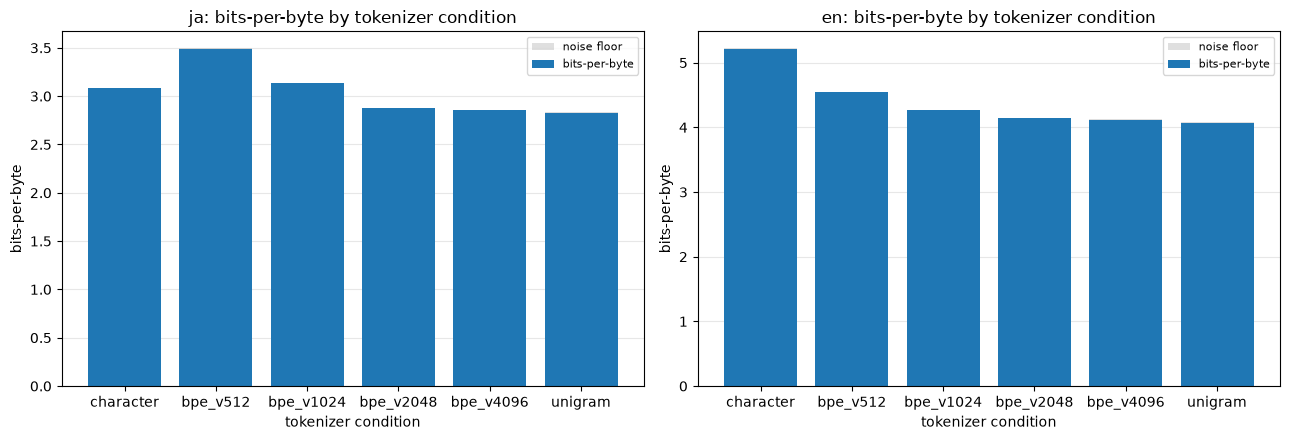

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, lang in zip(axes, ("ja", "en")):
    plot_grouped_bar(
        {"bits-per-byte": {name: final_bpb[lang][name] for name in tokenizer_conditions}},
        title=f"{lang}: bits-per-byte by tokenizer condition",
        ylabel="bits-per-byte",
        xlabel="tokenizer condition",
        ax=ax,
        noise_band=noise_floor[lang],
    )
fig.tight_layout()
plt.show()

#### 実験 D の交絡: 条件ごとの消化バイト数・エポック数

In [24]:
print(f"{'lang':4s} {'condition':12s} {'train_bytes':>12s} {'train_tokens':>12s} {'digested_bytes':>15s} {'epochs':>8s}")
for lang in ("ja", "en"):
    for name in tokenizer_conditions:
        r = shared_runs[(lang, name)]
        tokens_per_step = BATCH_SIZE * SEQUENCE_LENGTH
        total_tokens_seen = tokens_per_step * NUM_STEPS
        bytes_per_token = r["train_bytes"] / r["train_tokens"]
        digested_bytes = total_tokens_seen * bytes_per_token
        epochs = digested_bytes / r["train_bytes"]
        print(f"{lang:4s} {name:12s} {r['train_bytes']:12,d} {r['train_tokens']:12,d} {digested_bytes:15,.0f} {epochs:8.2f}")

lang condition     train_bytes train_tokens  digested_bytes   epochs
ja   character         380,084      131,088         139,545     0.37
ja   bpe_v512          380,084      168,565         108,520     0.29
ja   bpe_v1024         380,084      128,695         142,140     0.37
ja   bpe_v2048         380,084      106,043         172,503     0.45
ja   bpe_v4096         380,084       96,910         188,759     0.50
ja   unigram           380,084      106,867         171,172     0.45
en   character         380,097      376,657          48,568     0.13
en   bpe_v512          380,097      221,212          82,696     0.22
en   bpe_v1024         380,097      182,524         100,224     0.26
en   bpe_v2048         380,097      162,652         112,469     0.30
en   bpe_v4096         380,097      149,716         122,187     0.32
en   unigram           380,097      166,115         110,124     0.29


### 実験 G: 選定条件での本学習

**検証すること**: 実験 D〜F で選定したトークナイザ条件で、より多いステップ数(`G_NUM_STEPS`、5.6 節)で日英各 1 ラン学習し、学習が実際に進行するかを確認する。**model サイズは実験 C〜F と完全に同一のまま変えない**(本番実行前の修正 7)。model サイズを同時に変えると、性能向上が model サイズの増加によるものかステップ数の増加によるものか分離できなくなるためである。model サイズと性能の関係は 009(スケーリング則)の主題であり、006 では変数として扱わない。

**選定方法**: 実験 D〜F の判定が「判定不能」に終わった場合(スモークテストでは高い確率でそうなる、6 節冒頭の注記)、統計的な支持が得られた条件がないため、暫定的に **最終検証 bits-per-byte が最小だった条件** を選定する(参考程度の選定であることを明記する。本番で D〜F が支持を示せば、その結果に基づいて選定し直す)。

**判定基準(事前登録、本番実行前に改訂)**:
- 検証 bits-per-byte が学習を通じて **単調に改善する**(各評価点が直前の評価点以下)
- 最終値が同条件の短時間学習(実験 D〜F、`NUM_STEPS` ステップ)の値を下回る

In [25]:
selected_condition = {}
for lang in ("ja", "en"):
    best_name = min(tokenizer_conditions, key=lambda name: final_bpb[lang][name])
    selected_condition[lang] = best_name
    print(f"{lang}: 選定条件 = {best_name}(bits-per-byte = {final_bpb[lang][best_name]:.4f})")

ja: 選定条件 = unigram(bits-per-byte = 2.8253)
en: 選定条件 = unigram(bits-per-byte = 4.0672)


In [26]:
t0 = time.time()
experiment_g_runs = {}
for lang in ("ja", "en"):
    experiment_g_runs[lang] = run_condition(lang, selected_condition[lang], seed=0, extended=True)
    print(f"{lang}: 完了(経過 {time.time()-t0:.0f}s)")
print(f"\n合計実行時間: {time.time() - t0:.1f}s")

ja: 完了(経過 2s)


en: 完了(経過 4s)

合計実行時間: 4.1s


In [27]:
for lang in ("ja", "en"):
    history = experiment_g_runs[lang]["history"]
    short_run_bpb = final_bpb[lang][selected_condition[lang]]
    final_g_bpb = history["eval_bits_per_byte"][-1]
    bpb_series = history["eval_bits_per_byte"]
    is_monotonic = all(bpb_series[i] >= bpb_series[i + 1] for i in range(len(bpb_series) - 1))
    below_short_run = final_g_bpb < short_run_bpb
    print(
        f"{lang}({selected_condition[lang]}): "
        f"検証 bits-per-byte 推移 = {[round(v, 4) for v in bpb_series]}"
    )
    print(
        f"  単調改善: {is_monotonic}  最終値 {final_g_bpb:.4f} < 短時間学習の値 {short_run_bpb:.4f}: {below_short_run}  "
        f"(判定基準を満たすか: {is_monotonic and below_short_run})"
    )

ja(unigram): 検証 bits-per-byte 推移 = [3.0593, 2.8919, 2.7668, 2.6876, 2.6475]
  単調改善: True  最終値 2.6475 < 短時間学習の値 2.8253: True  (判定基準を満たすか: True)
en(unigram): 検証 bits-per-byte 推移 = [4.4769, 4.1741, 3.981, 3.8756, 3.8254]
  単調改善: True  最終値 3.8254 < 短時間学習の値 4.0672: True  (判定基準を満たすか: True)


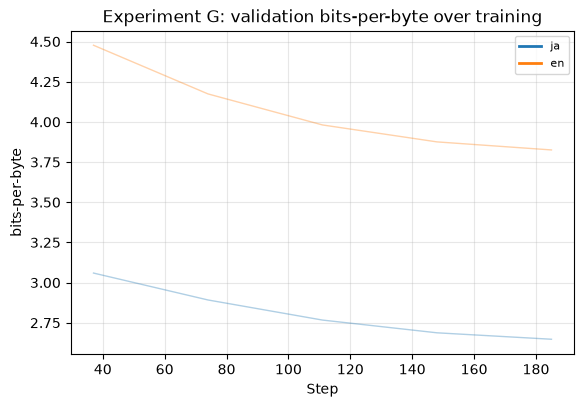

In [28]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
plot_learning_curves_multi_seed(
    {lang: [{"step": experiment_g_runs[lang]["history"]["eval_step"], "evaluation_loss": experiment_g_runs[lang]["history"]["eval_bits_per_byte"]}] for lang in ("ja", "en")},
    step_key="step",
    value_key="evaluation_loss",
    title="Experiment G: validation bits-per-byte over training",
    ylabel="bits-per-byte",
    ax=ax,
)
plt.show()

### 実験 H: 素朴な学習設定の限界の観測

**検証すること**: 実験 G の学習中に記録した勾配ノルム(`train_language_model` が gradient clipping なしで測定した値)と訓練損失の推移を観察し、素朴な学習設定(Adam・固定学習率・gradient clipping なし)の限界の兆候(勾配ノルムのスパイク、損失の発散など)が見られるかを定性的に観察する。追加の学習は不要(実験 G の履歴をそのまま使う)。

**判定基準を設けない**。定性的な観察であることを明記する。

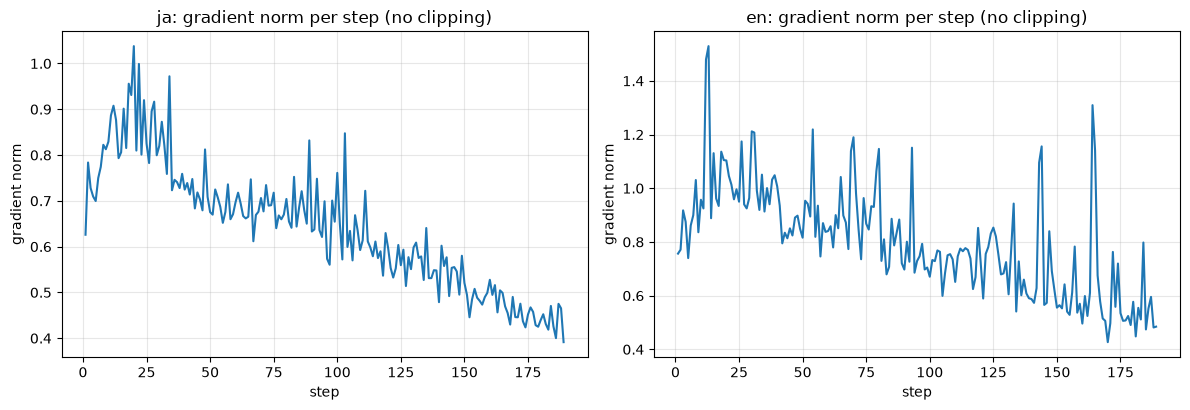

ja: gradient_norm min=0.391 max=1.038 mean=0.641 std=0.136
en: gradient_norm min=0.427 max=1.529 mean=0.799 std=0.201


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for lang, ax in zip(("ja", "en"), axes):
    history = experiment_g_runs[lang]["history"]
    ax.plot(history["step"], history["gradient_norm"])
    ax.set_title(f"{lang}: gradient norm per step (no clipping)")
    ax.set_xlabel("step")
    ax.set_ylabel("gradient norm")
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

for lang in ("ja", "en"):
    gn = experiment_g_runs[lang]["history"]["gradient_norm"]
    print(f"{lang}: gradient_norm min={min(gn):.3f} max={max(gn):.3f} mean={np.mean(gn):.3f} std={np.std(gn):.3f}")

### 生成例(greedy と temperature)

実験 G で学習した model(選定条件・`G_NUM_STEPS` ステップ)を使い、`generate()`(貪欲法と temperature sampling のみ、3.1 節)で生成した例を示す。デコーディング手法どうしの比較(top-k・top-p・beam search を含む)は 008 で扱うため、ここでは動作確認としての 2 例のみを示す。学習量がスモークテスト規模(`G_NUM_STEPS` ステップのみ)であるため、生成テキストは流暢さに欠けることが予想される(本番では Colab T4 での大規模な学習後に再生成する)。

In [30]:
for lang in ("ja", "en"):
    model = experiment_g_runs[lang]["model"].to(device)
    tokenizer = tokenizers[lang][selected_condition[lang]]
    prompt_text = val_text[lang][:20]
    prompt_ids = encode_corpus(tokenizer, prompt_text).unsqueeze(0).to(device)

    greedy_ids = model.generate(prompt_ids, max_new_tokens=30, temperature=0.0)
    sampled_ids = model.generate(prompt_ids, max_new_tokens=30, temperature=0.8, seed=0)

    print(f"=== {lang}({selected_condition[lang]}) ===")
    print(f"prompt: {prompt_text!r}")
    print(f"greedy (temperature=0.0): {tokenizer.decode(greedy_ids[0].cpu().tolist())!r}")
    print(f"sampled (temperature=0.8): {tokenizer.decode(sampled_ids[0].cpu().tolist())!r}")
    print()

=== ja(unigram) ===
prompt: '「閃IV」でパンタグリュエルでティータ、'
greedy (temperature=0.0): '「閃IV」でパンタグリュエルでティータ、、、、、、、、、、、、、、、、、、、、、、、、、、、、、、、'
sampled (temperature=0.8): '「閃IV」でパンタグリュエルでティータ、として作戦にはが本にに対してはクにでは復ともりから、「り所属�作�ラ屈あり果た、「を。校'



=== en(unigram) ===
prompt: 'st-primary)\nJoint Ac'
greedy (temperature=0.0): 'st-primary)\nJoint Ac\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n'
sampled (temperature=0.8): 'st-primary)\nJoint Acter Cge toashimerurumionla voiulationu, aa adjectives ofli (P tennstralalt\n theo'



## 7. 結果・考察 / Results and Discussion

**実行環境についての重要な注記**: 以下はすべて Claude Code によるローカル(Apple Silicon MPS)実行の結果であり、5.1 節で述べた通りコーパス・語彙サイズ・ステップ数を大幅に縮小したスモークテストである。**Google Colab T4 GPU での本番実行(`SMOKE_TEST=False`、本番スケールのコーパス・語彙サイズ・ステップ数)後、以下の数値・図はすべて再測定して更新する必要がある。** 更新が必要な箇所の一覧は本節末尾にまとめる。

**本節の構成についての注記**: 6 節冒頭で述べた通り、本番実行前に判定基準を改訂した(実験 D・E・F・G)。以下 7.1〜7.7 節は **改訂後の新基準** による結果である。改訂前(旧基準)によるスモークテスト結果は削除せず、7.8 節に「旧基準による結果」として保持する。

### 7.1 各実験の判定結果(新基準、事前登録した判定基準に照らして)

| 実験 | 判定基準(新) | 結果 |
|---|---|---|
| A | 全条件で $\lvert \text{loss} - \ln V \rvert < 0.05$(検証窓全体を使用、修正 12) | **満たす**(12 条件すべてで diff は 0.0044〜0.0164) |
| B | 位置 $t+1$ 以降の変更による位置 $t$ の logits の変化 $< 10^{-5}$ | **満たす**(実測 $0.00 \times 10^{0}$、完全に不変) |
| C | 判定基準なし(測定のみ、日英それぞれ 5 シードで測定、修正 11) | $\sigma_{\text{ja}} = 0.00570$、$\sigma_{\text{en}} = 0.00911$ |
| D(日本語) | 差 $> 2\sqrt{2}\,\sigma_{\text{ja}} = 0.0161$ | **満たす**(差 0.2569) → **支持** |
| D(英語) | 差 $> 2\sqrt{2}\,\sigma_{\text{en}} = 0.0258$ | **満たす**(差 1.1474) → **支持** |
| E(日本語) | $d_1, d_2 > 2\sqrt{6}\,\sigma_{\text{ja}} = 0.0279$(単調減少) | **満たす**($d_1{=}0.0962$、$d_2{=}0.2444$) → **支持** |
| E(英語) | $d_1, d_2 > 2\sqrt{6}\,\sigma_{\text{en}} = 0.0446$ | **満たす**($d_1{=}0.1586$、$d_2{=}0.0948$) → **支持** |
| F | 差 $> 4\,\sigma_{\text{rel}} = 0.0088$ | **満たす**(差 0.0868) → **支持** |
| G(日本語) | 単調改善 かつ 最終値 $<$ 短時間学習の値 | **満たす**(単調改善 True、$2.6475 < 2.8253$) |
| G(英語) | 同上 | **満たす**(単調改善 True、$3.8254 < 4.0672$) |
| H | 判定基準なし(定性的観察) | 7.4 節参照 |

**ステップ数の決定結果(修正 10)**: 全 12 条件中、最小の訓練トークン数を持つ条件は `ja/bpe_v4096`(96,910 トークン)であり、これを基準に $\text{NUM\_STEPS} = 94$($\text{EPOCH\_CAP\_CF}=0.5$)、$\text{G\_NUM\_STEPS} = 189$($\text{EPOCH\_CAP\_G}=1.0$)と計算された。全 12 条件のエポック数がそれぞれの上限(0.5・1.0)以内であることをアサーションで確認した(6 節、最大は `ja/bpe_v4096` 自身の 0.4966・0.9985 エポック)。

**未知トークン率・ラウンドトリップの検証結果(修正 1)**: 全 12 条件で `decode(encode(text)) == text` の完全一致、未知トークン率 0.000000 を確認した。

**分母(total_bytes)の一致の検証結果(修正 2)**: 日本語 19,915 バイト、英語 19,903 バイトで、全 5 トークナイザ条件について完全に同一であることを確認した。

**実験 A・B は理論的に必然な性質を検証するものであり、スモークテストの縮小スケールでも本番と同じ結論になることが期待される。** 一方、C〜G は測定対象の値そのものがスケールに強く依存するため、上記の「支持」という判定は **このスモークテストの縮小スケールに限定した結果** であり、本番スケールでの再検証が必須である。

### 7.2 実験 D・E・F: 数値の詳細(新基準)

| 条件 | 日本語 bits-per-byte | 英語 bits-per-byte |
|---|---:|---:|
| character(陰性対照) | 3.0822 | 5.2146 |
| BPE $V{=}512$ | 3.4903 | 4.5448 |
| BPE $V{=}1024$ | 3.1333 | 4.2636 |
| BPE $V{=}2048$ | 2.8725 | 4.1410 |
| BPE $V{=}4096$ | 2.8561 | 4.1132 |
| Unigram $V{=}2048$(`byte_fallback=True`、`character_coverage=1.0`) | **2.8253** | **4.0672** |

**実験 D(部分語 < 文字レベル)**: 日英とも、最良の部分語条件(いずれも Unigram)が文字レベルを新しい閾値($2\sqrt{2}\,\sigma_{\text{lang}}$)を大幅に超えて下回った(日本語: 差 0.2569 対 閾値 0.0161。英語: 差 1.1474 対 閾値 0.0258)。**支持** された。

**実験 E(語彙サイズ増加の収穫逓減、BPE 4 点、単調減少)**: 日本語では隣接差 $d_1{=}0.0962$、$d_2{=}0.2444$、英語では $d_1{=}0.1586$、$d_2{=}0.0948$ であり、日英とも改善幅が単調に減少し、$d_1$・$d_2$ とも新しい閾値($2\sqrt{6}\,\sigma_{\text{lang}}$)を超えた。**支持** された。

**実験 F(語彙サイズ効果は日本語の方が大きいか)**: $V_1{\to}V_4$($512 \to 4096$)の相対改善率は日本語 18.17%、英語 9.50% であり、差(8.68%)は保守的な相対ノイズ床($4\sigma_{\text{rel}} = 0.88\%$)を大きく超えた。**支持** された。

### 7.3 事後的な解釈(結果を見た後に立てた解釈であることを明示する)

以下は事前登録した判定基準による結論ではなく、**結果を見た後に立てた解釈** である。

- **未知語を解消した結果、Unigram の bits-per-byte のみが大きく悪化し、他条件はほぼ変化しなかった。** 7.8 節の旧基準(`byte_fallback=False`、`character_coverage=0.9995`)と比較すると、日本語の Unigram は $2.4871 \to 2.8253$ へ **0.338 悪化** した一方、同じ期間の日本語文字レベルは $3.2032 \to 3.0822$ とほぼ横ばい(NUM_STEPS の変更などによる通常のばらつきの範囲)である。英語でも Unigram は $3.9713 \to 4.0672$ へ **0.096 悪化** し、文字レベルは $5.4440 \to 5.2146$ とほぼ横ばいだった。Unigram だけが選択的に悪化したことは、旧基準での Unigram の大きな優位が、条件間で唯一 Unigram だけが背負っていた「未知語トークンへの情報の潰し込み」という **測定上の人工物(artifact)** に大部分を負っていたことを強く示唆する。
- **語彙サイズを揃えた新しい比較でも、Unigram はなお僅かに優位である。** 新基準では Unigram($V{=}2048$)と語彙サイズを厳密に揃えた BPE($V{=}2048$)を直接比較できる(修正 4)。差は日本語で $2.8725 - 2.8253 = 0.0472$、英語で $4.1410 - 4.0672 = 0.0738$ であり、実験 D の対比量の標準偏差($\sqrt{2}\,\sigma_{\text{lang}}$)と比べると、日本語で約 5.9 倍($0.0472 / (\sqrt{2}\times0.0057)$)、英語で約 5.7 倍($0.0738 / (\sqrt{2}\times0.0091)$)に相当する。ノイズ床の数倍の差ではあるが、旧基準で観測された効果量(未知語込みで文字レベルとの差が 0.71・1.47 に達していた、7.8.2 節)と比べると **一桁近く縮んでいる**。1 シードのみの観察であり、統計的な検定は行っていない。
- **この経緯自体が、指標の定義と符号化の可逆性を検証しないまま条件間比較を行うことの危険性を示す事例である。** 未知語による情報損失(修正 1 で発見)を見落としたまま旧基準の結果だけを見ていれば、「Unigram 言語モデルは文字レベル・BPE のいずれよりも大幅に優れる」という、実際には artifact に起因する誤った結論を導いていたことになる。ラウンドトリップの完全一致・未知トークン率 0 を明示的に検証する仕組み(5.4 節)を用意したことで、この誤りに気づき修正できた。
- **実験 F で日本語の方が語彙サイズ効果が大きかった** ことは、005 で確認した「日本語は空白による事前分割が機能せず、文字単位の粒度が細かいままだと系列が長くなりやすい」という性質と整合的である。この傾向は未知語を解消した新基準でも一貫して観測された。
- **語彙品質の診断量(6 節、修正 18)を踏まえた解釈**: [Google Colab T4 GPU での本番実行後に埋める。本番の語彙使用率・低頻度語彙の割合の表を参照し、実験 E で観測された収穫逓減のうち、真の収穫逓減(語彙サイズが大きいほど 1 トークンに詰め込める情報量が増えることによる本質的な改善)と、トークナイザ学習データ(`TOKENIZER_TRAIN_BYTES`)の不足による見かけの収穫逓減(大きい語彙サイズほど末尾のマージが低頻度ペアに基づくものになり、語彙使用率が下がることによる劣化)をどの程度切り分けられるかを記述する。語彙使用率が語彙サイズの増加とともに顕著に下がっている場合、実験 E の支持 / 反証 / 判定不能の判定そのものは変わらないとしても、その解釈(なぜ収穫逓減が起きたか)は慎重に扱う必要がある。]

### 7.4 実験 H: 素朴な学習設定の限界の観測

実験 G(選定条件 Unigram、model サイズは D〜F と同一、$\text{G\_NUM\_STEPS}=189$)の学習中に記録した勾配ノルム(gradient clipping なし)は、日本語で平均 0.641(標準偏差 0.136、範囲 [0.391, 1.038])、英語で平均 0.799(標準偏差 0.201、範囲 [0.427, 1.529])であり、**このスモークテストの範囲では明確なスパイクや発散は観測されなかった**。ステップ数がごく少ない(189 ステップ)ため、学習が不安定化する前に終了した可能性が高く、素朴な学習設定(Adam・固定学習率・gradient clipping なし)の限界を十分に観察できたとは言えない。

**007(学習の安定化)への動機**: 本トピックでは意図的に AdamW・学習率スケジュール・gradient clipping・mixed precision を実装しなかった(5 節冒頭)。実験 H で勾配ノルムを記録する仕組み自体は用意したが、スモークテストの短い学習では素朴な設定の限界(勾配爆発、学習率の過不足による発散・停滞)を引き出すには至らなかった。本番スケール(より多いステップ数)では、勾配ノルムのスパイクや損失の発散がより顕在化する可能性があり、007 でこれらの技術を導入する動機になる。

### 7.5 生成例の考察

6 節の生成例では、貪欲法(temperature=0.0)が日英とも同じトークンの繰り返し(日本語: 読点相当のトークン「、」、英語: 改行)に収束した。**修正 1 により未知語トークン `<unk>` への収束は解消された**(旧基準 7.8.5 節と比較すると、これは明確な改善である)。ただし、収束先が「未知語」から「特定の頻出トークン」に変わっただけであり、これは学習不足の言語モデルによくみられる別の失敗モード(高頻度トークンへの退化)である。temperature sampling(0.8)では、この退化は回避され、より多様なトークン列が生成されたが、文法的にも意味的にも一貫性は依然として欠けている。これらは本番の大規模な学習(Google Colab T4、フルスケールのコーパス・ステップ数)によって改善されることが期待される。デコーディング手法どうしの体系的な比較(top-k・top-p・beam search を含む)は 008 で扱う。

### 7.6 非埋め込みパラメータ数について

3.3 節で述べた通り、本トピックでは語彙サイズが条件間で異なる(181〜4096)ため、条件間の公平な比較のために非埋め込みパラメータ数を揃えた(全条件で 98,752、7.2 節の表)。総パラメータ数は埋め込み層(重み共有により 1 セット)の分だけ語彙サイズに応じて変動するが、Transformer Block 自体の「計算能力」を表す非埋め込みパラメータ数は不変である。この考え方(総パラメータ数ではなく非埋め込みパラメータ数を基準にする)は、Kaplan et al. [6] のスケーリング則の定式化と同じであり、009(スケーリング則)でモデルサイズと性能の関係を扱う際の土台になる。本トピックでは、非埋め込みパラメータあたりの消化トークン数が計算最適の目安(約 20 トークン)を大きく下回る、意図的に計算最適でない設定を採用している(5.1 節末尾を参照)。

### 7.7 Google Colab T4 GPU での再実行後に更新が必要な箇所

以下はすべて、本番スケール(`SMOKE_TEST=False`、20 MB 以上のコーパス・語彙サイズ 1024/2048/4096/8192・6 節末尾で計算式により決定するステップ数)での再実行後に、実測値へ差し替える必要がある。

1. **実行時間の較正セル(5.1 節直後)の実測値**: 1 ステップあたりの時間(スモークテストでは 5.8 ms)。本番の model サイズ(`D_MODEL=256` など)・`SEQUENCE_LENGTH=256`・`BATCH_SIZE=32` での実測値に差し替える。
2. **BPE 学習時間のスケーリング計測セル(6 節、`build_tokenizers` 呼び出し直前)の実測値**: スモークテストでは日本語の推定べき指数 $b{=}1.280$、英語 $b{=}1.163$(日本語の方が空白による事前分割が効かず、データ量に対する計算量の増加が急である)。`merge_ratio`(4 語彙サイズ分の補正係数)込みの `TOKENIZER_TRAIN_BYTES=2{,}000{,}000` への外挿値に差し替える。
3. **符号化時間のスケーリング計測セル(6 節、修正 20)の実測値**: スモークテストでは日本語の推定べき指数 $b{=}1.229$、英語 $b{=}1.016$。`LM_CORPUS_BYTES` の訓練分割全体・6 条件分への外挿値(スモークテストでは学習 9.0s + 符号化 40.0s = 合計 49.1s、30 分の閾値を大きく下回り警告なし)を実測値に差し替える。
4. **語彙品質の診断量の表(6 節、修正 18)**: スモークテストでの語彙使用率・低頻度語彙の割合(本節末尾の表を参照)を、本番スケールでの実測値に差し替える。
5. **6 節の `NUM_STEPS`・`G_NUM_STEPS` の実際の値と、全条件のエポック数の表、および見積もり総実行時間**: スモークテストでは `NUM_STEPS=94`・`G_NUM_STEPS=189`(制約条件: `ja/bpe_v4096`)、見積もり総実行時間 0.2 分だった。本番では 1 と組み合わせて再計算される。見積もりが 2 時間を大きく超える場合は `BATCH_SIZE`・`D_MODEL` を下げる方向で調整する(実行時間の較正の節末尾のコメント)。
6. **実験 A〜H のすべての数値出力**(loss・ln(V)・diff、日英それぞれのノイズ床、bits-per-byte、パラメータ数、勾配ノルム統計)と、対応する図(6 節の bits-per-byte 棒グラフ、実験 G の学習曲線、実験 H の勾配ノルム推移)。
7. **7.1 節の判定結果の表**: 本番スケールでの実測値に基づき、支持 / 反証 / 判定不能を再判定する(本スモークテストの「支持」がそのまま本番でも成り立つとは限らない)。
8. **7.2 節・7.3 節の数値と考察**: 特に「Unigram が両言語で僅かに優位」「日本語の方が語彙サイズ効果が大きい」という観察、および語彙品質の診断量を踏まえた実験 E の解釈(7.3 節末尾の空欄)は、本番スケールで再確認・記述する必要がある。
9. **7.4 節の勾配ノルムの観察**: 本番のステップ数(スモークテストの数倍〜十数倍)では、スモークテストでは見られなかった不安定化の兆候が現れる可能性がある。
10. **7.5 節の生成例**: 本番の学習量であれば、頻出トークンへの退化は解消される可能性が高い。生成例を再取得して差し替える。
11. **実験 D の交絡の表(6 節末尾の消化バイト数・エポック数の表)**: コーパスサイズが本番では大きくなるため、エポック数も本番の目標(実験 C〜F は 1/2 エポック以内、実験 G は 1 エポック以内)に沿って変わる。

### 7.8 旧基準による結果(本番実行前の改訂前、参考として保持)

**以下は、6 節冒頭で述べた判定基準の改訂を行う前に得られていたスモークテストの結果である。** 語彙サイズの刻み(等比数列でない 3 点)・ノイズ床(英語のみで測定)・判定閾値(誤差伝播を考慮しない一律 $2\sigma$)・実験 G の model サイズ(実験 D〜F と異なる)が、改訂後の新基準による上記の結果と異なる点に注意する。数値は削除せず、改訂の前後でどう変わったかを比較できるようにするためにそのまま残す。

**実行環境についての注記(旧基準の結果について)**: 以下もローカル(Apple Silicon MPS)実行によるスモークテストの結果である。

#### 7.8.1 各実験の判定結果(旧基準)

| 実験 | 判定基準(旧) | 結果 |
|---|---|---|
| A | 全条件で $\lvert \text{loss} - \ln V \rvert < 0.05$ | **満たす**(10 条件すべてで diff は 0.0025〜0.0196) |
| B | 位置 $t+1$ 以降の変更による位置 $t$ の logits の変化 $< 10^{-5}$ | **満たす**(実測 $0.00 \times 10^{0}$、完全に不変) |
| C | 判定基準なし(測定のみ、英語のみで測定) | ノイズ床(3 シードの標準偏差)= **0.0117** |
| D(日本語) | 最良部分語が文字レベルをノイズ床の 2 倍超で下回る | **満たす**(差 0.7161 > 0.0234) → **支持** |
| D(英語) | 同上 | **満たす**(差 1.4727 > 0.0234) → **支持** |
| E(日本語) | 前半改善幅が後半改善幅をノイズ床の 2 倍超で上回る(語彙サイズ 3 点、等比でない) | **満たす**(差 0.0594 > 0.0234) → **支持** |
| E(英語) | 同上 | **満たす**(差 0.0978 > 0.0234) → **支持** |
| F | 日本語の相対改善率が英語を相対ノイズ床の 2 倍超で上回る | **満たす**(差 0.0352 > 0.0052) → **支持** |
| G(日本語) | 最終検証 bits-per-byte が短時間学習の値を下回る(model サイズも同時に変更) | **満たす**(2.2633 < 2.4871) |
| G(英語) | 同上 | **満たす**(3.6572 < 3.9713) |
| H | 判定基準なし(定性的観察) | 7.8.4 節参照 |

#### 7.8.2 実験 D・E・F: 数値の詳細(旧基準)

| 条件 | 日本語 bits-per-byte | 英語 bits-per-byte |
|---|---:|---:|
| character(陰性対照) | 3.2032 | 5.4440 |
| BPE $V{=}512$ | 3.5360 | 4.6655 |
| BPE $V{=}768$ | 3.3367 | 4.4748 |
| BPE $V{=}1024$ | 3.1968 | 4.3820 |
| Unigram $V{=}1536$(`byte_fallback=False`、`character_coverage=0.9995`) | **2.4871** | **3.9713** |

**実験 D(部分語 < 文字レベル)**: 日英とも、最良の部分語条件(いずれも Unigram)が文字レベルを大きく下回った(日本語: 差 0.7161、ノイズ床の 2 倍 0.0234 を大幅に超過。英語: 差 1.4727、同様)。事前登録した判定基準のもとで両言語とも **支持** された。

**実験 E(語彙サイズ増加の収穫逓減、BPE のみ)**: 日本語では $V{:}512\to768$ の改善幅(0.1993)が $V{:}768\to1024$ の改善幅(0.1399)を上回り、英語でも同様の傾向(0.1907 対 0.0928)が見られた。いずれもノイズ床の 2 倍を超える差であり、**支持** された。ただし BPE $V{=}512$ が文字レベルより **悪化している**(日本語 3.5360 > 3.2032、英語 4.6655 < 5.4440 なので英語では改善している)点には注意が必要である。

**実験 F(語彙サイズ効果は日本語の方が大きいか)**: $V{:}512\to1024$ の相対改善率は日本語 9.59%、英語 6.08% であり、差(3.52%)は相対ノイズ床の 2 倍(0.52%)を大きく超えた。**支持** された。

**旧基準の Unigram 条件についての重要な注記**: 上記の Unigram 条件は `byte_fallback=False`・`character_coverage=0.9995`(sentencepiece の既定)で学習しており、**未知語による情報損失を含んでいる**(修正 1 で述べた問題)。このため「Unigram が両言語で最良」という旧基準の観察は、方式そのものの優位性ではなく、未知語への情報損失によって負の対数尤度が不当に下がった結果である可能性が高い。新基準(7.2 節)での再測定によって、この観察がどう変わったかを比較すること。

#### 7.8.3 事後的な解釈(旧基準の結果を見た後に立てた解釈)

- **Unigram 言語モデルが両言語で最良だった** のは、実験 D・E・F の判定基準(BPE の語彙サイズ効果、文字レベルとの比較)が直接検証した対象ではなく、あくまで付随的な観察である。Unigram の語彙サイズ($V{=}1536$)が BPE の最大条件($V{=}1024$)よりも大きいことに加え、7.8.2 節で述べた未知語による情報損失も優位性の一因である可能性がある。
- **実験 F で日本語の方が語彙サイズ効果が大きかった** ことは、005 で確認した「日本語は空白による事前分割が機能せず、文字単位の粒度が細かいままだと系列が長くなりやすい」という性質と整合的である。

#### 7.8.4 実験 H: 素朴な学習設定の限界の観測(旧基準、model サイズがより大きい)

実験 G(選定条件 Unigram、`d_model=96`・3 層という、当時は D〜F より大きい model)の学習中に記録した勾配ノルム(gradient clipping なし)は、日本語で平均 0.852(標準偏差 0.244、範囲 [0.416, 1.376])、英語で平均 0.881(標準偏差 0.262、範囲 [0.488, 1.573])であり、明確なスパイクや発散は観測されなかった。

#### 7.8.5 生成例の考察(旧基準)

貪欲法(temperature=0.0)がプロンプトの直後から `<unk>` トークンの繰り返しに陥った(日英とも)。これは 7.8.2 節で述べた未知語による情報損失(Unigram が `<unk>` に過度に依存していた)が直接の原因である可能性が高い。新基準(`byte_fallback=True`)での再生成結果を 7.5 節で確認すること。